# Intelligent SDN Security Framework
### Evolutionary Architecture Search (ENAS) + GAN-based Adversarial Learning for SDN Intrusion Detection

This notebook is a single, linearly-runnable version of the full project
(originally organised as separate `.py` modules). Run the cells **top to
bottom**.

**Pipeline:** raw CSV → preprocessing (leakage-safe train/val/test split,
encoding, scaling) → Evolutionary Neural Architecture Search (genetic
algorithm over MLP architectures) → GAN-based adversarial augmentation of
the *training split only* → side-by-side comparison of the ENAS classifier
**with** vs **without** GAN augmentation.

**Before running:** place your raw dataset at
`data/final_binary_raw_dataset.csv` (relative to wherever this notebook
lives), or change `RAW_CSV_PATH` in the Configuration cell below.


## 0. Install dependencies
Run once if the packages aren't already installed in your Jupyter environment.

In [1]:
import torch
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())

2.5.1+cu121 12.1 True


## 1. Configuration
All paths and hyperparameters in one place (mirrors `config.py` from the original project).

In [2]:
import os
import torch

import os
import torch

# --------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()  # notebook working directory

RAW_CSV_PATH = os.path.join(PROJECT_ROOT, "data", "final_binary_raw_dataset.csv")

ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")
PROCESSED_DIR = os.path.join(ARTIFACTS_DIR, "processed")
ENAS_DIR = os.path.join(ARTIFACTS_DIR, "enas")
GAN_DIR = os.path.join(ARTIFACTS_DIR, "gan")
RESULTS_DIR = os.path.join(ARTIFACTS_DIR, "results")

PREPROCESSOR_PATH = os.path.join(PROCESSED_DIR, "preprocessor.pkl")
FEATURE_COLUMNS_PATH = os.path.join(PROCESSED_DIR, "feature_columns.json")
LABEL_ENCODER_PATH = os.path.join(PROCESSED_DIR, "label_encoder.pkl")

TRAIN_PATH = os.path.join(PROCESSED_DIR, "train.npz")
VAL_PATH = os.path.join(PROCESSED_DIR, "val.npz")
TEST_PATH = os.path.join(PROCESSED_DIR, "test.npz")

BEST_ARCH_PATH = os.path.join(ENAS_DIR, "best_architecture.json")
BEST_MODEL_NO_GAN_PATH = os.path.join(ENAS_DIR, "best_model_no_gan.pt")
BEST_MODEL_GAN_PATH = os.path.join(ENAS_DIR, "best_model_gan.pt")
GAN_GENERATOR_PATH = os.path.join(GAN_DIR, "generator.pt")
COMPARISON_RESULTS_PATH = os.path.join(RESULTS_DIR, "comparison_results.json")
COMPARISON_TABLE_CSV = os.path.join(RESULTS_DIR, "comparison_table.csv")

for d in [ARTIFACTS_DIR, PROCESSED_DIR, ENAS_DIR, GAN_DIR, RESULTS_DIR,
          os.path.join(PROJECT_ROOT, "data")]:
    os.makedirs(d, exist_ok=True)

# --------------------------------------------------------------------------
# Reproducibility / device
# --------------------------------------------------------------------------
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------------------------------
# Data columns (per the raw dataset schema described in the proposal)
# --------------------------------------------------------------------------
LABEL_COLUMN = "label"

# Columns dropped because they are identifiers or would leak information
# that will not be available/meaningful in a real-time deployment scenario
# (e.g. raw IP/MAC addresses could let the model memorize hosts instead of
# learning behavioural flow patterns -> leakage / poor generalisation).
DROP_COLUMNS = [
    "flowInd", "srcIP", "dstIP", "srcMac", "dstMac",
    "srcIPCC", "dstIPCC", "srcIPOrg", "dstIPOrg",
    "timeFirst", "timeLast", "hdrDesc",
]

# Numerical flow-statistics columns that are typically heavy-tailed /
# skewed (packet counts, byte counts, inter-arrival times, rates, etc.)
LOG_TRANSFORM_COLUMNS = [
    "duration", "pktsSnt", "pktsRcvd", "padBytesSnt", "l7BytesSnt",
    "l7BytesRcvd", "minL7PktSz", "maxL7PktSz", "avgL7PktSz", "stdL7PktSz",
    "minIAT", "maxIAT", "avgIAT", "stdIAT", "pktps", "bytps",
    "pktAsm", "bytAsm",
]

# Categorical columns to one-hot encode
CATEGORICAL_COLUMNS = [
    "%dir", "flowStat", "ethType", "vlanID", "l4Proto",
    "srcPort_bucket", "dstPort_bucket",
]

# Port fields that get bucketed + service-flagged
PORT_COLUMNS = ["srcPort", "dstPort"]

# Well-known SDN/network service ports to flag explicitly - these are
# frequently targeted in reconnaissance / saturation / evasion attacks,
# so making them explicit binary features helps the model key on them
# even after heavy scaling of the continuous features.
SERVICE_PORTS = [
    20, 21, 22, 23, 25, 53, 67, 68, 69, 80, 110, 123, 135, 137, 138, 139,
    143, 161, 389, 443, 445, 993, 995, 1433, 3306, 3389, 5432, 5900, 8080,
]

# Numerical columns that are NOT log-transformed but still need scaling
# (the log-transformed columns above are also scaled downstream, plus the
# binary service-flag / bucket columns are left untouched by the scaler).
OTHER_NUMERIC_COLUMNS = ["numHdrDesc", "numHdrs"]

# --------------------------------------------------------------------------
# Train / val / test split
# --------------------------------------------------------------------------
TEST_SIZE = 0.15
VAL_SIZE = 0.15  # relative to the remaining (train+val) data after test split
CHUNK_SIZE = 200_000  # rows per chunk when reading very large CSVs

# --------------------------------------------------------------------------
# ENAS (Evolutionary Neural Architecture Search) search space
# --------------------------------------------------------------------------
SEARCH_SPACE = {
    "n_layers": [1, 2, 3, 4, 5],
    "units": [32, 64, 128, 256, 512],
    "activation": ["relu", "leaky_relu", "gelu"],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr": [1e-4, 3e-4, 1e-3],
    "batch_size": [256, 512, 1024],
}

GA_POPULATION_SIZE = 12
GA_GENERATIONS = 8
GA_ELITISM_COUNT = 2
GA_TOURNAMENT_SIZE = 3
GA_MUTATION_RATE = 0.25
GA_CROSSOVER_RATE = 0.8
GA_TRAIN_EPOCHS = 6          # short training budget used purely for *fitness evaluation*
GA_FINAL_TRAIN_EPOCHS = 30   # full training budget for the final best model

# --------------------------------------------------------------------------
# GAN hyperparameters
# --------------------------------------------------------------------------
GAN_NOISE_DIM = 32
GAN_EPOCHS = 200
GAN_BATCH_SIZE = 256
GAN_LR_G = 2e-4
GAN_LR_D = 2e-4
GAN_SYNTH_RATIO = 0.5  # synthetic attack samples added = ratio * (#real attack train samples)

## 2. Utilities
Seeding + a tiny logger (mirrors `utils/common.py`).

In [3]:
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """Seed every RNG we use so experiments are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def log(msg: str) -> None:
    """Simple timestamp-free print wrapper (kept as a single choke point
    so it is trivial to swap for the `logging` module later)."""
    print(f"[SDN-Security] {msg}")

## 3. Data Preprocessing
Mirrors `preprocessing/preprocess.py`:
- loads the raw CSV (chunk-capable for large files)
- drops identifier/leakage columns
- buckets ports, adds service-port flags, log1p-transforms skewed columns
- **splits into train/val/test BEFORE fitting any encoder/scaler**
  (fit only on train, transform all splits with that same fitted object)
- saves `preprocessor.pkl`, `feature_columns.json`, `label_encoder.pkl`, and the processed `.npz` splits


In [4]:
import json
import os

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler

class BinaryLabelEncoder:
    """
    A minimal, explicit stand-in for sklearn's LabelEncoder.

    We deliberately do NOT use sklearn.preprocessing.LabelEncoder here
    because it sorts classes alphabetically, which would silently map
    ATTACK -> 0 and NORMAL -> 1. Every downstream component in this
    project (GAN attack-mask selection, false positive/negative rate
    computation, class-imbalance weighting, etc.) assumes the convention
    "1 == ATTACK / positive class, 0 == NORMAL / negative class", so we
    fix that mapping explicitly and permanently here instead of leaving
    it to an arbitrary sort order.
    """

    def __init__(self):
        self.classes_ = np.array(["NORMAL", "ATTACK"])
        self._map = {"NORMAL": 0, "ATTACK": 1}
        self._inverse_map = {0: "NORMAL", 1: "ATTACK"}

    def fit(self, labels):
        unique = set(str(l).strip().upper() for l in labels)
        unexpected = unique - set(self._map.keys())
        if unexpected:
            raise ValueError(
                f"Unexpected label values found: {unexpected}. "
                f"Expected only 'NORMAL' and 'ATTACK'."
            )
        return self

    def transform(self, labels):
        return np.array([self._map[str(l).strip().upper()] for l in labels])

    def fit_transform(self, labels):
        self.fit(labels)
        return self.transform(labels)

    def inverse_transform(self, encoded):
        return np.array([self._inverse_map[int(e)] for e in encoded])

# --------------------------------------------------------------------------
# Step 1: Loading
# --------------------------------------------------------------------------
def load_raw_data(csv_path: str, chunksize: int = None) -> pd.DataFrame:
    """
    Load the raw CSV. If `chunksize` is given, the file is streamed in
    chunks and concatenated -- this keeps peak memory usage bounded when
    the raw dataset is very large, while still returning a single
    DataFrame for the (vectorised, pandas-native) feature engineering
    steps that follow.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Could not find raw dataset at '{csv_path}'. "
            f"Place 'final_binary_raw_dataset.csv' under the data/ folder "
            f"or update RAW_CSV_PATH."
        )

    if chunksize:
        log(f"Loading '{csv_path}' in chunks of {chunksize} rows ...")
        chunks = []
        for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize, low_memory=False)):
            chunks.append(chunk)
            log(f"  loaded chunk {i + 1} ({len(chunk)} rows)")
        df = pd.concat(chunks, ignore_index=True)
    else:
        log(f"Loading '{csv_path}' ...")
        df = pd.read_csv(csv_path, low_memory=False)

    log(f"Raw dataset shape: {df.shape}")
    return df

# --------------------------------------------------------------------------
# Step 2: Drop leakage / identifier columns
# --------------------------------------------------------------------------
def drop_leakage_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
    missing = set(DROP_COLUMNS) - set(cols_to_drop)
    if missing:
        log(f"  note: some drop-columns not present in CSV (skipped): {missing}")
    df = df.drop(columns=cols_to_drop)
    log(f"Dropped {len(cols_to_drop)} identifier/leakage columns -> shape {df.shape}")
    return df

# --------------------------------------------------------------------------
# Step 3a: Port bucketing
# --------------------------------------------------------------------------
def _bucket_single_port(port) -> str:
    """Map a single port number to a coarse bucket category."""
    if pd.isna(port):
        return "missing"
    try:
        p = int(float(port))
    except (ValueError, TypeError):
        return "missing"

    if 0 <= p <= 1023:
        return "well_known"
    elif 1024 <= p <= 49151:
        return "registered"
    elif 49152 <= p <= 65535:
        return "ephemeral"
    else:
        return "other"

def bucket_ports(df: pd.DataFrame) -> pd.DataFrame:
    for col in PORT_COLUMNS:
        if col in df.columns:
            df[f"{col}_bucket"] = df[col].apply(_bucket_single_port)
    log("Bucketed srcPort / dstPort into well_known / registered / ephemeral / other.")
    return df

# --------------------------------------------------------------------------
# Step 3b: Service-port binary flags
# --------------------------------------------------------------------------
def add_service_flags(df: pd.DataFrame) -> pd.DataFrame:
    for col in PORT_COLUMNS:
        if col not in df.columns:
            continue
        numeric_col = pd.to_numeric(df[col], errors="coerce")
        for svc_port in SERVICE_PORTS:
            df[f"{col}_svc_{svc_port}"] = (numeric_col == svc_port).astype(int)
    n_flags = 2 * len(SERVICE_PORTS)
    log(f"Added {n_flags} binary service-port flag columns.")
    return df

# --------------------------------------------------------------------------
# Step 3c: log1p transform of skewed numeric columns
# --------------------------------------------------------------------------
def apply_log_transform(df: pd.DataFrame) -> pd.DataFrame:
    for col in LOG_TRANSFORM_COLUMNS:
        if col in df.columns:
            numeric_col = pd.to_numeric(df[col], errors="coerce").fillna(0)
            # clip at 0 because log1p is undefined for values < -1; flow
            # statistics should never legitimately be negative.
            df[col] = np.log1p(numeric_col.clip(lower=0))
    log(f"Applied log1p transform to {len(LOG_TRANSFORM_COLUMNS)} skewed numeric columns.")
    return df

# --------------------------------------------------------------------------
# Full deterministic feature-engineering pass (no fitting involved)
# --------------------------------------------------------------------------
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = bucket_ports(df)
    df = add_service_flags(df)
    df = apply_log_transform(df)

    # srcPort/dstPort themselves are now redundant with the bucket +
    # service-flag features and are extremely high-cardinality, so we
    # drop the raw port numbers to avoid the model memorising individual
    # ports instead of learning generalisable behaviour.
    df = df.drop(columns=[c for c in PORT_COLUMNS if c in df.columns])

    return df

# --------------------------------------------------------------------------
# Step 4: Stratified train / val / test split
# --------------------------------------------------------------------------
def stratified_split(df: pd.DataFrame, label_col: str, test_size: float,
                      val_size: float, seed: int):
    """
    First split off the test set, then split the remainder into
    train/val. `val_size` is expressed relative to the *remaining*
    (train+val) portion so the final proportions match the configured
    fractions of the *original* dataset.
    """
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df[label_col], random_state=seed
    )
    train_df, val_df = train_test_split(
        train_val_df, test_size=val_size, stratify=train_val_df[label_col],
        random_state=seed,
    )
    log(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
        dist = part[label_col].value_counts(normalize=True).round(3).to_dict()
        log(f"  {name} label distribution: {dist}")
    return train_df, val_df, test_df

# --------------------------------------------------------------------------
# Step 5: Fit encoder/scaler on TRAIN ONLY, transform all splits
# --------------------------------------------------------------------------
def build_and_fit_preprocessor(train_df: pd.DataFrame):
    categorical_cols = [c for c in CATEGORICAL_COLUMNS if c in train_df.columns]
    numeric_cols = [c for c in (LOG_TRANSFORM_COLUMNS + OTHER_NUMERIC_COLUMNS)
                     if c in train_df.columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
            ("num", RobustScaler(), numeric_cols),
        ],
        remainder="passthrough",  # keeps the binary service-flag columns as-is
    )

    # Determine the passthrough (binary flag) columns explicitly so we can
    # reconstruct readable feature names afterwards.
    used_cols = set(categorical_cols) | set(numeric_cols)
    passthrough_cols = [c for c in train_df.columns if c not in used_cols and c != LABEL_COLUMN]

    feature_input_cols = categorical_cols + numeric_cols + passthrough_cols

    X_train_raw = train_df[feature_input_cols]
    preprocessor.fit(X_train_raw)

    log(f"Fitted preprocessor on TRAIN ONLY: {len(categorical_cols)} categorical, "
        f"{len(numeric_cols)} numeric (scaled), {len(passthrough_cols)} passthrough binary columns.")

    # Build readable output feature names
    ohe = preprocessor.named_transformers_["cat"]
    cat_feature_names = list(ohe.get_feature_names_out(categorical_cols)) if categorical_cols else []
    output_feature_names = cat_feature_names + numeric_cols + passthrough_cols

    return preprocessor, feature_input_cols, output_feature_names

def transform_split(preprocessor, feature_input_cols, df: pd.DataFrame):
    X = preprocessor.transform(df[feature_input_cols])
    return np.asarray(X, dtype=np.float32)

# --------------------------------------------------------------------------
# Step 6: Save everything
# --------------------------------------------------------------------------
def save_artifacts(preprocessor, output_feature_names, label_encoder,
                    train_X, train_y, val_X, val_y, test_X, test_y):
    joblib.dump(preprocessor, PREPROCESSOR_PATH)
    joblib.dump(label_encoder, LABEL_ENCODER_PATH)

    with open(FEATURE_COLUMNS_PATH, "w") as f:
        json.dump(output_feature_names, f, indent=2)

    np.savez_compressed(TRAIN_PATH, X=train_X, y=train_y)
    np.savez_compressed(VAL_PATH, X=val_X, y=val_y)
    np.savez_compressed(TEST_PATH, X=test_X, y=test_y)

    log(f"Saved preprocessor -> {PREPROCESSOR_PATH}")
    log(f"Saved feature columns ({len(output_feature_names)}) -> {FEATURE_COLUMNS_PATH}")
    log(f"Saved label encoder -> {LABEL_ENCODER_PATH}")
    log(f"Saved train/val/test arrays -> {PROCESSED_DIR}")

# --------------------------------------------------------------------------
# Orchestration
# --------------------------------------------------------------------------
def run_preprocessing(csv_path: str = None, use_chunks: bool = False):
    set_seed(RANDOM_SEED)
    csv_path = csv_path or RAW_CSV_PATH

    df = load_raw_data(csv_path, chunksize=CHUNK_SIZE if use_chunks else None)

    if LABEL_COLUMN not in df.columns:
        raise ValueError(f"Expected label column '{LABEL_COLUMN}' not found in dataset.")

    # Drop exact duplicate rows / rows with a missing label - both are
    # cheap, safe hygiene steps that do not depend on train/test split.
    before = len(df)
    df = df.dropna(subset=[LABEL_COLUMN])
    df = df.drop_duplicates()
    log(f"Dropped {before - len(df)} duplicate/unlabeled rows -> shape {df.shape}")

    df = drop_leakage_columns(df)
    df = engineer_features(df)

    # Encode label as 0/1 (NORMAL/ATTACK) - fit on the full label column is
    # safe since it only ever sees the two fixed class strings, not any
    # numeric feature statistics.
    label_encoder = BinaryLabelEncoder()
    df[LABEL_COLUMN] = label_encoder.fit_transform(df[LABEL_COLUMN].astype(str))
    log(f"Label classes: {list(label_encoder.classes_)} -> {list(range(len(label_encoder.classes_)))}")

    train_df, val_df, test_df = stratified_split(
        df, LABEL_COLUMN, TEST_SIZE, VAL_SIZE, RANDOM_SEED
    )

    preprocessor, feature_input_cols, output_feature_names = build_and_fit_preprocessor(train_df)

    train_X = transform_split(preprocessor, feature_input_cols, train_df)
    val_X = transform_split(preprocessor, feature_input_cols, val_df)
    test_X = transform_split(preprocessor, feature_input_cols, test_df)

    train_y = train_df[LABEL_COLUMN].to_numpy()
    val_y = val_df[LABEL_COLUMN].to_numpy()
    test_y = test_df[LABEL_COLUMN].to_numpy()

    save_artifacts(preprocessor, output_feature_names, label_encoder,
                    train_X, train_y, val_X, val_y, test_X, test_y)

    log("Preprocessing complete.")
    return train_X, train_y, val_X, val_y, test_X, test_y

Run preprocessing now (this populates the train/val/test arrays used by every later cell).

In [5]:
train_X, train_y, val_X, val_y, test_X, test_y = run_preprocessing()
print("Shapes:", train_X.shape, val_X.shape, test_X.shape)


[SDN-Security] Loading '/home/manasvi/sdn_notebook_final/data/final_binary_raw_dataset.csv' ...
[SDN-Security] Raw dataset shape: (2000000, 40)
[SDN-Security] Dropped 0 duplicate/unlabeled rows -> shape (2000000, 40)
[SDN-Security] Dropped 12 identifier/leakage columns -> shape (2000000, 28)
[SDN-Security] Bucketed srcPort / dstPort into well_known / registered / ephemeral / other.
[SDN-Security] Added 58 binary service-port flag columns.
[SDN-Security] Applied log1p transform to 18 skewed numeric columns.
[SDN-Security] Label classes: [np.str_('NORMAL'), np.str_('ATTACK')] -> [0, 1]
[SDN-Security] Split sizes -> train: 1445000, val: 255000, test: 300000
[SDN-Security]   train label distribution: {0: 0.5, 1: 0.5}
[SDN-Security]   val label distribution: {0: 0.5, 1: 0.5}
[SDN-Security]   test label distribution: {0: 0.5, 1: 0.5}
[SDN-Security] Fitted preprocessor on TRAIN ONLY: 7 categorical, 20 numeric (scaled), 58 passthrough binary columns.
[SDN-Security] Saved preprocessor -> /home/

## 4. Model: Configurable MLP
Mirrors `models/mlp.py`. Architecture is built dynamically from a gene dict produced by the GA.

In [6]:
import torch
import torch.nn as nn

ACTIVATIONS = {
    "relu": nn.ReLU,
    "leaky_relu": lambda: nn.LeakyReLU(0.01),
    "gelu": nn.GELU,
}

class ConfigurableMLP(nn.Module):
    """
    Builds a feed-forward network from an architecture gene:
        {
            "n_layers": int,
            "units": [int, ...]        # length == n_layers
            "activation": "relu" | "leaky_relu" | "gelu",
            "dropout": float,
        }
    Output layer is a single logit (binary classification via BCEWithLogitsLoss).
    """

    def __init__(self, input_dim: int, arch: dict):
        super().__init__()
        self.arch = arch

        activation_cls = ACTIVATIONS[arch["activation"]]
        layers = []
        in_dim = input_dim

        for units in arch["units"][: arch["n_layers"]]:
            layers.append(nn.Linear(in_dim, units))
            layers.append(nn.BatchNorm1d(units))
            layers.append(activation_cls())
            if arch["dropout"] > 0:
                layers.append(nn.Dropout(arch["dropout"]))
            in_dim = units

        layers.append(nn.Linear(in_dim, 1))  # single logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)  # (batch,) raw logits

## 5. ENAS Search Space
Mirrors `enas/search_space.py`: gene sampling, mutation, and crossover operators.

In [7]:
import random

MAX_LAYERS = max(SEARCH_SPACE["n_layers"])

def sample_architecture() -> dict:
    """Randomly sample one architecture from the search space (uniform)."""
    ss = SEARCH_SPACE
    return {
        "n_layers": random.choice(ss["n_layers"]),
        "units": [random.choice(ss["units"]) for _ in range(MAX_LAYERS)],
        "activation": random.choice(ss["activation"]),
        "dropout": random.choice(ss["dropout"]),
        "lr": random.choice(ss["lr"]),
        "batch_size": random.choice(ss["batch_size"]),
    }

def init_population(pop_size: int) -> list:
    return [sample_architecture() for _ in range(pop_size)]

def mutate(arch: dict, mutation_rate: float) -> dict:
    """
    Gene-wise mutation: each field independently has `mutation_rate`
    probability of being resampled from the search space. Returns a new
    dict (does not mutate in place) to keep individuals immutable.
    """
    ss = SEARCH_SPACE
    child = dict(arch)
    child["units"] = list(arch["units"])  # deep-copy the list field

    if random.random() < mutation_rate:
        child["n_layers"] = random.choice(ss["n_layers"])
    if random.random() < mutation_rate:
        child["activation"] = random.choice(ss["activation"])
    if random.random() < mutation_rate:
        child["dropout"] = random.choice(ss["dropout"])
    if random.random() < mutation_rate:
        child["lr"] = random.choice(ss["lr"])
    if random.random() < mutation_rate:
        child["batch_size"] = random.choice(ss["batch_size"])

    for i in range(MAX_LAYERS):
        if random.random() < mutation_rate:
            child["units"][i] = random.choice(ss["units"])

    return child

def crossover(parent_a: dict, parent_b: dict) -> tuple:
    """
    Uniform crossover: for each gene field, each child independently
    inherits the value from either parent with 50% probability. The
    `units` list undergoes per-slot uniform crossover as well.
    Returns two children (child_a, child_b).
    """
    def make_child(p1, p2):
        child = {}
        for key in ["n_layers", "activation", "dropout", "lr", "batch_size"]:
            child[key] = p1[key] if random.random() < 0.5 else p2[key]
        child["units"] = [
            p1["units"][i] if random.random() < 0.5 else p2["units"][i]
            for i in range(MAX_LAYERS)
        ]
        return child

    child_a = make_child(parent_a, parent_b)
    child_b = make_child(parent_b, parent_a)
    return child_a, child_b

def arch_to_str(arch: dict) -> str:
    """Human-readable one-liner, handy for logging."""
    used_units = arch["units"][: arch["n_layers"]]
    return (f"layers={arch['n_layers']} units={used_units} "
            f"act={arch['activation']} drop={arch['dropout']} "
            f"lr={arch['lr']} batch={arch['batch_size']}")

## 6. ENAS Training / Evaluation Utilities
Mirrors `enas/train_utils.py`: shared train/eval routines (used both for fast GA fitness evaluation and full final-model evaluation).

In [8]:
import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

def _make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

def train_model(arch: dict, X_train: np.ndarray, y_train: np.ndarray,
                 epochs: int, input_dim: int, device=None,
                 class_weight: bool = True) -> ConfigurableMLP:
    """Train a ConfigurableMLP from scratch given an architecture gene."""
    device = device or DEVICE
    model = ConfigurableMLP(input_dim, arch).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=arch["lr"])

    if class_weight:
        # Handle any residual class imbalance in the (possibly GAN
        # augmented) training set via a positive-class weight.
        n_pos = max(int(y_train.sum()), 1)
        n_neg = max(len(y_train) - n_pos, 1)
        pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    loader = _make_loader(X_train, y_train, arch["batch_size"], shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        # (epoch-level loss intentionally not logged during GA fitness
        # evaluation to keep search output readable; final training logs
        # via the caller if desired)

    return model

@torch.no_grad()
def predict_proba(model: ConfigurableMLP, X: np.ndarray, device=None,
                   batch_size: int = 2048) -> np.ndarray:
    device = device or DEVICE
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    probs = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].to(device)
        logits = model(xb)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

def quick_val_f1(model: ConfigurableMLP, X_val: np.ndarray, y_val: np.ndarray, device=None) -> float:
    """Fast F1 computation used as the GA fitness signal."""
    probs = predict_proba(model, X_val, device=device)
    preds = (probs >= 0.5).astype(int)
    return f1_score(y_val, preds, zero_division=0)

@torch.no_grad()
def measure_inference_latency(model: ConfigurableMLP, X: np.ndarray, device=None,
                               n_samples: int = 1000) -> float:
    """
    Measures average inference latency PER FLOW in milliseconds, by
    timing single-sample forward passes (mirrors real-time, one-flow-at-
    a-time inference in an SDN controller pipeline).
    """
    device = device or DEVICE
    model.eval()
    n_samples = min(n_samples, len(X))
    idx = np.random.choice(len(X), size=n_samples, replace=False)
    X_t = torch.tensor(X[idx], dtype=torch.float32).to(device)

    # warm-up (avoids measuring one-off CUDA/JIT overhead)
    for i in range(min(10, n_samples)):
        _ = model(X_t[i:i + 1])

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for i in range(n_samples):
        _ = model(X_t[i:i + 1])
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return (elapsed / n_samples) * 1000.0  # ms per flow

def full_evaluate(model: ConfigurableMLP, X: np.ndarray, y: np.ndarray, device=None) -> dict:
    """Compute the full metric suite required by the proposal."""
    device = device or DEVICE
    probs = predict_proba(model, X, device=device)
    preds = (probs >= 0.5).astype(int)

    cm = confusion_matrix(y, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    try:
        roc_auc = roc_auc_score(y, probs)
    except ValueError:
        roc_auc = float("nan")  # only one class present in y

    latency_ms = measure_inference_latency(model, X, device=device)

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1_score": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "inference_latency_ms_per_flow": latency_ms,
    }

## 7. Genetic Algorithm (Evolutionary Architecture Search)
Mirrors `enas/genetic_algorithm.py`: init population → fitness=val F1 → tournament selection → crossover → mutation → elitism → repeat for N generations.

In [9]:
import json
import random

import numpy as np
import torch

class EvolutionarySearch:
    def __init__(self, X_train, y_train, X_val, y_val, input_dim,
                 population_size=None, generations=None, device=None):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.input_dim = input_dim
        self.population_size = population_size or GA_POPULATION_SIZE
        self.generations = generations or GA_GENERATIONS
        self.device = device or DEVICE

        self.population = init_population(self.population_size)
        self.history = []  # per-generation best/avg fitness, for reporting

    # ----------------------------------------------------------------
    def evaluate_fitness(self, arch: dict) -> float:
        """Train briefly, return validation F1 as the fitness score."""
        model = train_model(
            arch, self.X_train, self.y_train,
            epochs=GA_TRAIN_EPOCHS, input_dim=self.input_dim,
            device=self.device,
        )
        return quick_val_f1(model, self.X_val, self.y_val, device=self.device)

    # ----------------------------------------------------------------
    def tournament_select(self, pop_with_fitness: list) -> dict:
        """Pick the best of `GA_TOURNAMENT_SIZE` random individuals."""
        contenders = random.sample(pop_with_fitness, GA_TOURNAMENT_SIZE)
        contenders.sort(key=lambda pf: pf[1], reverse=True)
        return contenders[0][0]

    # ----------------------------------------------------------------
    def run(self) -> dict:
        best_arch = None
        best_fitness = -1.0

        for gen in range(self.generations):
            log(f"=== GA Generation {gen + 1}/{self.generations} ===")

            # 1. Evaluate fitness for the whole population
            pop_with_fitness = []
            for i, arch in enumerate(self.population):
                fitness = self.evaluate_fitness(arch)
                pop_with_fitness.append((arch, fitness))
                log(f"  ind {i + 1}/{len(self.population)} | val_F1={fitness:.4f} | {arch_to_str(arch)}")

            pop_with_fitness.sort(key=lambda pf: pf[1], reverse=True)
            gen_best_arch, gen_best_fit = pop_with_fitness[0]
            gen_avg_fit = float(np.mean([f for _, f in pop_with_fitness]))

            log(f"  Generation {gen + 1} summary: best_F1={gen_best_fit:.4f}, avg_F1={gen_avg_fit:.4f}")
            self.history.append({"generation": gen + 1, "best_f1": gen_best_fit, "avg_f1": gen_avg_fit})

            if gen_best_fit > best_fitness:
                best_fitness = gen_best_fit
                best_arch = gen_best_arch

            # 2. Elitism: carry the top-K individuals forward unchanged
            elites = [arch for arch, _ in pop_with_fitness[: GA_ELITISM_COUNT]]

            # 3. Build the rest of the next generation via selection + crossover + mutation
            next_population = list(elites)
            while len(next_population) < self.population_size:
                parent_a = self.tournament_select(pop_with_fitness)
                parent_b = self.tournament_select(pop_with_fitness)

                if random.random() < GA_CROSSOVER_RATE:
                    child_a, child_b = crossover(parent_a, parent_b)
                else:
                    child_a, child_b = dict(parent_a), dict(parent_b)

                child_a = mutate(child_a, GA_MUTATION_RATE)
                child_b = mutate(child_b, GA_MUTATION_RATE)

                next_population.append(child_a)
                if len(next_population) < self.population_size:
                    next_population.append(child_b)

            self.population = next_population

        log(f"GA search complete. Best val_F1={best_fitness:.4f} | {arch_to_str(best_arch)}")
        return best_arch, best_fitness, self.history

def run_search_and_train_final(X_train, y_train, X_val, y_val, X_test, y_test,
                                input_dim, save_prefix: str = "no_gan"):
    """
    Convenience wrapper: run the GA search, then fully retrain the best
    architecture on the (possibly GAN-augmented) training set and
    evaluate it on val + test.
    """
    searcher = EvolutionarySearch(X_train, y_train, X_val, y_val, input_dim)
    best_arch, best_val_f1, history = searcher.run()

    log(f"Retraining best architecture with full budget ({GA_FINAL_TRAIN_EPOCHS} epochs) ...")
    final_model = train_model(
        best_arch, X_train, y_train,
        epochs=GA_FINAL_TRAIN_EPOCHS, input_dim=input_dim,
        device=DEVICE,
    )

    val_metrics = full_evaluate(final_model, X_val, y_val, device=DEVICE)
    test_metrics = full_evaluate(final_model, X_test, y_test, device=DEVICE)

    log(f"[{save_prefix}] VAL metrics: {val_metrics}")
    log(f"[{save_prefix}] TEST metrics: {test_metrics}")

    # Persist best architecture + trained weights
    arch_path = BEST_ARCH_PATH.replace(".json", f"_{save_prefix}.json")
    with open(arch_path, "w") as f:
        json.dump({"architecture": best_arch, "val_f1_during_search": best_val_f1,
                    "ga_history": history}, f, indent=2)

    model_path = (BEST_MODEL_GAN_PATH if save_prefix == "gan"
                  else BEST_MODEL_NO_GAN_PATH)
    torch.save({"state_dict": final_model.state_dict(),
                "architecture": best_arch, "input_dim": input_dim}, model_path)

    log(f"Saved best architecture -> {arch_path}")
    log(f"Saved trained model -> {model_path}")

    return {
        "architecture": best_arch,
        "val_f1_during_search": best_val_f1,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "ga_history": history,
        "model_path": model_path,
        "arch_path": arch_path,
    }

## 8. Tabular GAN (Generator / Discriminator)
Mirrors `gan/tabular_gan.py`.

In [10]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim: int, output_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, output_dim),
            nn.Tanh(),  # bounded output in [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),  # logit (real vs fake)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

## 9. GAN Training + Synthetic Attack Generation
Mirrors `gan/train_gan.py`.

**Important:** the GAN is trained **only** on ATTACK-class rows of the
training split, and synthetic samples are concatenated **only** into the
training set — validation/test always stay 100% real.


In [11]:
import numpy as np
import torch
import torch.nn as nn

def _to_unit_range(X: np.ndarray):
    """
    Rescale features to [-1, 1] for stable GAN training (matches the
    Generator's tanh output). Returns rescaled array plus the (min, max)
    needed to invert the transform later.
    """
    X_min = X.min(axis=0, keepdims=True)
    X_max = X.max(axis=0, keepdims=True)
    denom = np.where((X_max - X_min) == 0, 1.0, X_max - X_min)
    X_unit = 2 * (X - X_min) / denom - 1
    return X_unit.astype(np.float32), X_min, X_max

def _from_unit_range(X_unit: np.ndarray, X_min: np.ndarray, X_max: np.ndarray) -> np.ndarray:
    return ((X_unit + 1) / 2) * (X_max - X_min) + X_min

def train_gan_on_attack_samples(X_train: np.ndarray, y_train: np.ndarray,
                                 device=None, epochs=None, batch_size=None,
                                 noise_dim=None, verbose_every=20):
    """
    Trains Generator + Discriminator on the real ATTACK rows of the
    training split. Returns (generator, X_min, X_max) so callers can
    later invert the [-1, 1] rescaling of any generated samples.
    """
    device = device or DEVICE
    epochs = epochs or GAN_EPOCHS
    batch_size = batch_size or GAN_BATCH_SIZE
    noise_dim = noise_dim or GAN_NOISE_DIM

    attack_mask = (y_train == 1)
    X_attack = X_train[attack_mask]
    log(f"Training GAN on {len(X_attack)} real ATTACK samples from the TRAIN split only.")

    if len(X_attack) < batch_size:
        batch_size = max(8, len(X_attack) // 2)
        log(f"  (few attack samples available; reduced GAN batch_size to {batch_size})")

    X_unit, X_min, X_max = _to_unit_range(X_attack)
    feature_dim = X_unit.shape[1]

    generator = Generator(noise_dim, feature_dim).to(device)
    discriminator = Discriminator(feature_dim).to(device)

    opt_g = torch.optim.Adam(generator.parameters(), lr=GAN_LR_G, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR_D, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    X_unit_t = torch.tensor(X_unit, dtype=torch.float32)
    n = len(X_unit_t)

    for epoch in range(epochs):
        perm = torch.randperm(n)
        d_loss_total, g_loss_total, n_batches = 0.0, 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            real_batch = X_unit_t[idx].to(device)
            cur_bs = real_batch.size(0)
            if cur_bs < 2:
                continue  # BatchNorm needs >=2 samples

            real_labels = torch.ones(cur_bs, device=device) * 0.9   # label smoothing
            fake_labels = torch.zeros(cur_bs, device=device)

            # ---- Train Discriminator ----
            opt_d.zero_grad()
            real_logits = discriminator(real_batch)
            d_loss_real = criterion(real_logits, real_labels)

            z = torch.randn(cur_bs, noise_dim, device=device)
            fake_batch = generator(z).detach()
            fake_logits = discriminator(fake_batch)
            d_loss_fake = criterion(fake_logits, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_d.step()

            # ---- Train Generator ----
            opt_g.zero_grad()
            z = torch.randn(cur_bs, noise_dim, device=device)
            fake_batch = generator(z)
            fake_logits = discriminator(fake_batch)
            # generator wants discriminator to classify fakes as real
            g_loss = criterion(fake_logits, torch.ones(cur_bs, device=device))
            g_loss.backward()
            opt_g.step()

            d_loss_total += d_loss.item()
            g_loss_total += g_loss.item()
            n_batches += 1

        if (epoch + 1) % verbose_every == 0 or epoch == epochs - 1:
            log(f"  GAN epoch {epoch + 1}/{epochs} | D_loss={d_loss_total / max(n_batches,1):.4f} "
                f"| G_loss={g_loss_total / max(n_batches,1):.4f}")

    torch.save({"generator_state_dict": generator.state_dict(),
                "noise_dim": noise_dim, "feature_dim": feature_dim,
                "X_min": X_min, "X_max": X_max}, GAN_GENERATOR_PATH)
    log(f"Saved trained GAN generator -> {GAN_GENERATOR_PATH}")

    return generator, X_min, X_max

@torch.no_grad()
def generate_synthetic_attacks(generator: Generator, n_samples: int,
                                X_min: np.ndarray, X_max: np.ndarray,
                                noise_dim=None, device=None) -> np.ndarray:
    """Generate `n_samples` synthetic ATTACK feature vectors in the
    ORIGINAL (already-encoded/scaled) feature space, ready to concatenate
    with real training data."""
    device = device or DEVICE
    noise_dim = noise_dim or GAN_NOISE_DIM

    generator.eval()
    z = torch.randn(n_samples, noise_dim, device=device)
    synthetic_unit = generator(z).cpu().numpy()
    synthetic = _from_unit_range(synthetic_unit, X_min, X_max)
    generator.train()
    return synthetic.astype(np.float32)

def augment_training_set_with_gan(X_train: np.ndarray, y_train: np.ndarray,
                                   synth_ratio=None, device=None):
    """
    Full augmentation pipeline:
      1. Train the GAN on real train-split attack samples only.
      2. Generate `synth_ratio * n_real_attack` synthetic attack samples.
      3. Concatenate with the ORIGINAL (real) training data.

    Returns the augmented (X, y) training arrays. y for synthetic rows is
    always 1 (ATTACK), since the generator is trained exclusively to
    model the attack-class distribution.
    """
    synth_ratio = synth_ratio if synth_ratio is not None else GAN_SYNTH_RATIO
    device = device or DEVICE

    generator, X_min, X_max = train_gan_on_attack_samples(X_train, y_train, device=device)

    n_real_attack = int((y_train == 1).sum())
    n_synth = max(1, int(round(n_real_attack * synth_ratio)))

    synthetic_X = generate_synthetic_attacks(generator, n_synth, X_min, X_max, device=device)
    synthetic_y = np.ones(n_synth, dtype=y_train.dtype)

    X_augmented = np.concatenate([X_train, synthetic_X], axis=0)
    y_augmented = np.concatenate([y_train, synthetic_y], axis=0)

    log(f"GAN augmentation: added {n_synth} synthetic ATTACK samples "
        f"({synth_ratio:.2f} x {n_real_attack} real attacks) -> "
        f"train set grew from {len(X_train)} to {len(X_augmented)} rows.")

    # shuffle so synthetic rows aren't all appended at the end (matters for
    # any mini-batch training that doesn't already shuffle, and is good
    # hygiene regardless)
    perm = np.random.permutation(len(X_augmented))
    return X_augmented[perm], y_augmented[perm]

## 10. Evaluation / Metrics Formatting
Mirrors `evaluation/metrics.py`.

In [12]:
METRIC_ORDER = [
    "accuracy", "precision", "recall", "f1_score", "roc_auc",
    "false_positive_rate", "false_negative_rate",
    "inference_latency_ms_per_flow",
]

def print_metrics(name: str, metrics: dict) -> None:
    log(f"--- {name} ---")
    for k in METRIC_ORDER:
        if k in metrics:
            log(f"  {k:32s}: {metrics[k]:.4f}")
    if "confusion_matrix" in metrics:
        log(f"  confusion_matrix [[TN,FP],[FN,TP]] : {metrics['confusion_matrix']}")

def metrics_to_flat_row(name: str, metrics: dict) -> dict:
    """Flatten a metrics dict into a single row suitable for a comparison table."""
    row = {"experiment": name}
    for k in METRIC_ORDER:
        row[k] = metrics.get(k, float("nan"))
    cm = metrics.get("confusion_matrix")
    if cm:
        row["TN"], row["FP"], row["FN"], row["TP"] = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return row

## 11. Full Comparison: ENAS without GAN vs. ENAS with GAN
Mirrors `evaluation/compare.py`. Runs both experiments end-to-end on the
preprocessed splits produced in section 3, and saves a comparison table.

Set `DISABLE_GAN = True` below to skip the GAN-augmentation experiment
(e.g. if your dataset is already close to balanced).


In [13]:
import argparse
import json
import os

import numpy as np
import pandas as pd

def load_processed_split(path: str):
    data = np.load(path)
    return data["X"], data["y"]

def run_comparison(disable_gan: bool = False):
    set_seed(RANDOM_SEED)

    log("Loading preprocessed train/val/test splits ...")
    X_train, y_train = load_processed_split(TRAIN_PATH)
    X_val, y_val = load_processed_split(VAL_PATH)
    X_test, y_test = load_processed_split(TEST_PATH)
    input_dim = X_train.shape[1]

    log(f"Shapes -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")
    log(f"Train class balance -> NORMAL: {(y_train == 0).sum()}, ATTACK: {(y_train == 1).sum()}")

    results = {}

    # ---------------------------------------------------------------
    # Experiment A: ENAS classifier WITHOUT GAN augmentation
    # ---------------------------------------------------------------
    log("\n########## EXPERIMENT A: ENAS (no GAN augmentation) ##########")
    result_no_gan = run_search_and_train_final(
        X_train, y_train, X_val, y_val, X_test, y_test,
        input_dim=input_dim, save_prefix="no_gan",
    )
    print_metrics("ENAS - NO GAN - TEST", result_no_gan["test_metrics"])
    results["enas_no_gan"] = result_no_gan

    # ---------------------------------------------------------------
    # Experiment B: ENAS classifier WITH GAN augmentation
    # ---------------------------------------------------------------
    if disable_gan:
        log("\n--disable-gan set: skipping GAN augmentation experiment "
            "(dataset assumed already near-balanced).")
    else:
        log("\n########## EXPERIMENT B: ENAS (with GAN augmentation) ##########")
        log("Training GAN on TRAIN split ATTACK samples only ...")
        X_train_aug, y_train_aug = augment_training_set_with_gan(X_train, y_train)
        log(f"Augmented train class balance -> NORMAL: {(y_train_aug == 0).sum()}, "
            f"ATTACK: {(y_train_aug == 1).sum()}")

        # NOTE: X_val / X_test are passed through completely untouched -
        # only the training arrays are augmented.
        result_gan = run_search_and_train_final(
            X_train_aug, y_train_aug, X_val, y_val, X_test, y_test,
            input_dim=input_dim, save_prefix="gan",
        )
        print_metrics("ENAS - WITH GAN - TEST", result_gan["test_metrics"])
        results["enas_with_gan"] = result_gan

    # ---------------------------------------------------------------
    # Build and save the comparison table
    # ---------------------------------------------------------------
    rows = []
    rows.append(metrics_to_flat_row("ENAS_no_GAN", results["enas_no_gan"]["test_metrics"]))
    if "enas_with_gan" in results:
        rows.append(metrics_to_flat_row("ENAS_with_GAN", results["enas_with_gan"]["test_metrics"]))

    comparison_df = pd.DataFrame(rows)
    comparison_df.to_csv(COMPARISON_TABLE_CSV, index=False)
    log(f"\nSaved comparison table -> {COMPARISON_TABLE_CSV}")
    log("\n" + comparison_df.to_string(index=False))

    with open(COMPARISON_RESULTS_PATH, "w") as f:
        json.dump({
            "enas_no_gan": {
                "architecture": results["enas_no_gan"]["architecture"],
                "val_metrics": results["enas_no_gan"]["val_metrics"],
                "test_metrics": results["enas_no_gan"]["test_metrics"],
            },
            **({
                "enas_with_gan": {
                    "architecture": results["enas_with_gan"]["architecture"],
                    "val_metrics": results["enas_with_gan"]["val_metrics"],
                    "test_metrics": results["enas_with_gan"]["test_metrics"],
                }
            } if "enas_with_gan" in results else {}),
        }, f, indent=2)
    log(f"Saved full comparison results -> {COMPARISON_RESULTS_PATH}")

    return results, comparison_df

Run the full comparison now:

In [14]:
DISABLE_GAN = False  # set True to skip the GAN-augmentation experiment

results, comparison_df = run_comparison(disable_gan=DISABLE_GAN)
comparison_df


[SDN-Security] Loading preprocessed train/val/test splits ...
[SDN-Security] Shapes -> train: (1445000, 122), val: (255000, 122), test: (300000, 122)
[SDN-Security] Train class balance -> NORMAL: 722500, ATTACK: 722500
[SDN-Security] 
########## EXPERIMENT A: ENAS (no GAN augmentation) ##########
[SDN-Security] === GA Generation 1/8 ===
[SDN-Security]   ind 1/12 | val_F1=0.9603 | layers=1 units=[32] act=gelu drop=0.0 lr=0.001 batch=1024
[SDN-Security]   ind 2/12 | val_F1=0.9604 | layers=5 units=[32, 512, 256, 32, 32] act=relu drop=0.1 lr=0.0001 batch=1024
[SDN-Security]   ind 3/12 | val_F1=0.9591 | layers=5 units=[32, 512, 64, 512, 256] act=relu drop=0.3 lr=0.001 batch=512
[SDN-Security]   ind 4/12 | val_F1=0.9628 | layers=1 units=[64] act=relu drop=0.2 lr=0.0001 batch=256
[SDN-Security]   ind 5/12 | val_F1=0.7836 | layers=4 units=[32, 128, 128, 512] act=relu drop=0.5 lr=0.0003 batch=1024
[SDN-Security]   ind 6/12 | val_F1=0.9609 | layers=1 units=[256] act=leaky_relu drop=0.4 lr=0.0001

,experiment,accuracy,precision,recall,f1_score,roc_auc,false_positive_rate,false_negative_rate,inference_latency_ms_per_flow,TN,FP,FN,TP
0,ENAS_no_GAN,0.962007,0.929385,0.999993,0.963397,0.995139,0.075980,0.000007,0.344402,138603,11397,1,149999
1,ENAS_with_GAN,0.961150,0.927907,0.999993,0.962603,0.995188,0.077693,0.000007,0.265742,138346,11654,1,149999


## 12. Inspect Results

- `results['enas_no_gan']` / `results['enas_with_gan']` contain the full
  architecture, validation metrics, and test metrics for each experiment.
- The comparison table is also saved to
  `artifacts/results/comparison_table.csv` and
  `artifacts/results/comparison_results.json`.


In [15]:
import json
print(json.dumps(results["enas_no_gan"]["architecture"], indent=2))
print()
print("Test metrics (no GAN):")
print(json.dumps(results["enas_no_gan"]["test_metrics"], indent=2))

if "enas_with_gan" in results:
    print()
    print(json.dumps(results["enas_with_gan"]["architecture"], indent=2))
    print()
    print("Test metrics (with GAN):")
    print(json.dumps(results["enas_with_gan"]["test_metrics"], indent=2))


{
  "n_layers": 4,
  "activation": "relu",
  "dropout": 0.1,
  "lr": 0.0001,
  "batch_size": 256,
  "units": [
    64,
    64,
    64,
    64,
    256
  ]
}

Test metrics (no GAN):
{
  "accuracy": 0.9620066666666667,
  "precision": 0.9293848670351186,
  "recall": 0.9999933333333333,
  "f1_score": 0.963397089236856,
  "roc_auc": 0.9951388971555556,
  "confusion_matrix": [
    [
      138603,
      11397
    ],
    [
      1,
      149999
    ]
  ],
  "false_positive_rate": 0.07598,
  "false_negative_rate": 6.666666666666667e-06,
  "inference_latency_ms_per_flow": 0.34440200007520616
}

{
  "n_layers": 3,
  "activation": "relu",
  "dropout": 0.1,
  "lr": 0.001,
  "batch_size": 512,
  "units": [
    32,
    256,
    128,
    256,
    64
  ]
}

Test metrics (with GAN):
{
  "accuracy": 0.96115,
  "precision": 0.9279073076280675,
  "recall": 0.9999933333333333,
  "f1_score": 0.9626026381905517,
  "roc_auc": 0.9951875756666666,
  "confusion_matrix": [
    [
      138346,
      11654
    ],
  

In [11]:
import os
import json
from pathlib import Path

# ------------------------------------------------------------
# Find the existing comparison_results.json automatically
# ------------------------------------------------------------

possible_paths = [
    Path("sdn_notebook_final/artifacts/results/comparison_results.json"),
    Path("artifacts/results/comparison_results.json"),
]

comparison_json = None

for path in possible_paths:
    if path.exists():
        comparison_json = path.resolve()
        break

if comparison_json is None:
    print("Current working directory:")
    print(os.getcwd())

    raise FileNotFoundError(
        "Could not locate comparison_results.json. "
        "Check the current working directory shown above."
    )

print("Found results file:")
print(comparison_json)


# ------------------------------------------------------------
# Derive all directories from the file we actually found
# ------------------------------------------------------------

RESULTS_DIR = comparison_json.parent

ARTIFACTS_DIR = RESULTS_DIR.parent

EXTENDED_RESULTS_DIR = (
    ARTIFACTS_DIR / "extended_results"
)

EXTENDED_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nFigures will be saved to:")
print(EXTENDED_RESULTS_DIR)


# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

with open(
    comparison_json,
    "r",
    encoding="utf-8"
) as f:
    loaded_results = json.load(f)


# ------------------------------------------------------------
# Determine JSON structure
# ------------------------------------------------------------

if "enas_no_gan" in loaded_results:

    results = loaded_results

elif (
    "experiments" in loaded_results
    and
    "enas_no_gan"
    in loaded_results["experiments"]
):

    results = loaded_results["experiments"]

else:

    print(
        "Available JSON keys:",
        list(loaded_results.keys())
    )

    raise KeyError(
        "'enas_no_gan' was not found "
        "in comparison_results.json"
    )


# ------------------------------------------------------------
# Experiments for plotting
# ------------------------------------------------------------

experiments_to_plot = [
    (
        "No GAN",
        results[
            "enas_no_gan"
        ]["test_metrics"]
    )
]

if "enas_with_gan" in results:

    experiments_to_plot.append(
        (
            "With GAN",
            results[
                "enas_with_gan"
            ]["test_metrics"]
        )
    )

PRIMARY_EXPERIMENT_KEY = "enas_no_gan"

SAVE_DPI = 150

print(
    "\nExperiments available for plotting:",
    [
        name
        for name, _
        in experiments_to_plot
    ]
)

Found results file:
/home/manasvi/sdn_notebook_final/artifacts/results/comparison_results.json

Results directory:
/home/manasvi/sdn_notebook_final/artifacts/results

Figures will be saved to:
/home/manasvi/sdn_notebook_final/artifacts/extended_results

Experiments available for plotting: ['No GAN', 'With GAN']


In [13]:
# ---------------------------------------------------------------------------
# Publication-quality visualization setup
#
# Automatically finds:
# comparison_results.json
#
# Figures are saved into:
# artifacts/extended_results/
# ---------------------------------------------------------------------------

import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch
)
import seaborn as sns


# ---------------------------------------------------------------------------
# 1. Plot style
# ---------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ---------------------------------------------------------------------------
# 2. Find comparison_results.json automatically
# ---------------------------------------------------------------------------

possible_paths = [

    # If notebook is running from parent directory
    Path(
        "sdn_notebook_final/"
        "artifacts/"
        "results/"
        "comparison_results.json"
    ),

    # If notebook is already inside sdn_notebook_final
    Path(
        "artifacts/"
        "results/"
        "comparison_results.json"
    ),
]


comparison_results_path = None

for path in possible_paths:

    if path.exists():

        comparison_results_path = path.resolve()

        break


# ---------------------------------------------------------------------------
# 3. If normal paths fail, search current workspace
# ---------------------------------------------------------------------------

if comparison_results_path is None:

    print(
        "Standard paths did not find "
        "comparison_results.json."
    )

    print(
        "Searching current workspace..."
    )

    matches = list(
        Path(".").rglob(
            "comparison_results.json"
        )
    )

    if matches:

        comparison_results_path = (
            matches[0].resolve()
        )


# ---------------------------------------------------------------------------
# 4. Stop with useful information if file is still not found
# ---------------------------------------------------------------------------

if comparison_results_path is None:

    print(
        "\nCurrent working directory:"
    )

    print(
        Path.cwd()
    )

    raise FileNotFoundError(
        "\nCould not locate "
        "comparison_results.json.\n"
        "Check the current working directory "
        "printed above."
    )


print(
    "\nFound results file:"
)

print(
    comparison_results_path
)


# ---------------------------------------------------------------------------
# 5. Derive directories automatically
#
# Expected:
#
# artifacts/
# ├── results/
# │   └── comparison_results.json
# │
# └── extended_results/
# ---------------------------------------------------------------------------

RESULTS_DIR = (
    comparison_results_path.parent
)

ARTIFACTS_DIR = (
    RESULTS_DIR.parent
)

EXTENDED_RESULTS_DIR = (
    ARTIFACTS_DIR
    / "extended_results"
)


# Create output directory
EXTENDED_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nResults directory:"
)

print(
    RESULTS_DIR
)


print(
    "\nArtifacts directory:"
)

print(
    ARTIFACTS_DIR
)


print(
    "\nFigures will be saved to:"
)

print(
    EXTENDED_RESULTS_DIR
)


# ---------------------------------------------------------------------------
# 6. Image quality
#
# 150 DPI gives smaller files than 300 DPI
# while remaining suitable for reports.
# ---------------------------------------------------------------------------

SAVE_DPI = 150


# ---------------------------------------------------------------------------
# 7. Load comparison results
# ---------------------------------------------------------------------------

with open(
    comparison_results_path,
    "r",
    encoding="utf-8"
) as f:

    loaded_results = json.load(f)


print(
    "\nTop-level JSON keys:"
)

print(
    list(loaded_results.keys())
)


# ---------------------------------------------------------------------------
# 8. Handle possible JSON structures
# ---------------------------------------------------------------------------

if "enas_no_gan" in loaded_results:

    results = loaded_results


elif (
    "experiments" in loaded_results
    and
    isinstance(
        loaded_results["experiments"],
        dict
    )
    and
    "enas_no_gan"
    in loaded_results["experiments"]
):

    results = (
        loaded_results["experiments"]
    )


else:

    raise KeyError(
        "\nCould not find "
        "'enas_no_gan' inside "
        "comparison_results.json.\n"
        f"Available top-level keys: "
        f"{list(loaded_results.keys())}"
    )


# ---------------------------------------------------------------------------
# 9. Experiments to visualize
# ---------------------------------------------------------------------------

experiments_to_plot = []


# No-GAN experiment
if "enas_no_gan" in results:

    if (
        "test_metrics"
        in results["enas_no_gan"]
    ):

        experiments_to_plot.append(
            (
                "No GAN",
                results[
                    "enas_no_gan"
                ][
                    "test_metrics"
                ]
            )
        )

    else:

        raise KeyError(
            "'test_metrics' not found "
            "inside 'enas_no_gan'."
        )


# GAN experiment, if available
if "enas_with_gan" in results:

    if (
        "test_metrics"
        in results["enas_with_gan"]
    ):

        experiments_to_plot.append(
            (
                "With GAN",
                results[
                    "enas_with_gan"
                ][
                    "test_metrics"
                ]
            )
        )


# ---------------------------------------------------------------------------
# 10. Primary experiment
# ---------------------------------------------------------------------------

PRIMARY_EXPERIMENT_KEY = (
    "enas_no_gan"
)


# ---------------------------------------------------------------------------
# 11. Final confirmation
# ---------------------------------------------------------------------------

print(
    "\nExperiments available for plotting:"
)

print(
    [
        name
        for name, _
        in experiments_to_plot
    ]
)

print(
    "\nSetup completed successfully."
)


Found results file:
/home/manasvi/sdn_notebook_final/artifacts/results/comparison_results.json

Results directory:
/home/manasvi/sdn_notebook_final/artifacts/results

Artifacts directory:
/home/manasvi/sdn_notebook_final/artifacts

Figures will be saved to:
/home/manasvi/sdn_notebook_final/artifacts/extended_results

Top-level JSON keys:
['enas_no_gan', 'enas_with_gan']

Experiments available for plotting:
['No GAN', 'With GAN']

Setup completed successfully.


Confusion matrix counts [enas_no_gan]:
TN = 138603
FP = 11397
FN = 1
TP = 149999


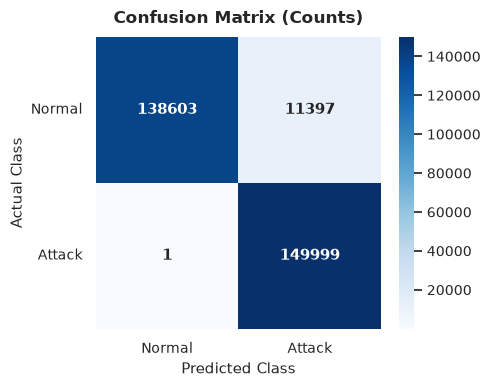

Saved -> /home/manasvi/sdn_notebook_final/artifacts/extended_results/figure2a_confusion_matrix_counts.png


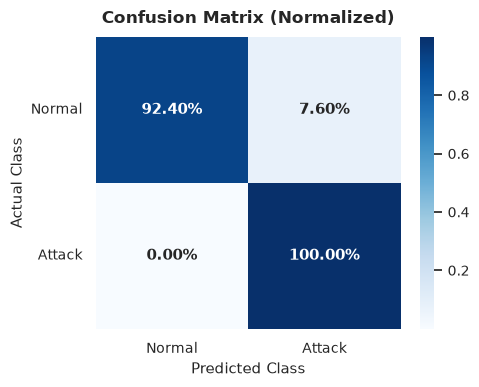

Saved -> /home/manasvi/sdn_notebook_final/artifacts/extended_results/figure2b_confusion_matrix_normalized.png


In [16]:
# ---------------------------------------------------------------------------
# Figure 2 — Confusion Matrix Heatmap
# Creates:
#   Figure 2a: Counts
#   Figure 2b: Normalized percentages
# ---------------------------------------------------------------------------

import numpy as np


def plot_confusion_matrix(
    cm,
    title,
    save_path,
    normalize=False
):
    cm = np.array(cm)

    # --------------------------------------------------------
    # Normalize row-wise if requested
    # --------------------------------------------------------
    if normalize:

        row_sums = cm.sum(
            axis=1,
            keepdims=True
        )

        # Prevent division by zero
        cm_display = np.divide(
            cm.astype(float),
            row_sums,
            out=np.zeros_like(
                cm,
                dtype=float
            ),
            where=row_sums != 0
        )

        fmt = ".2%"

    else:

        cm_display = cm

        fmt = "d"


    # --------------------------------------------------------
    # Smaller figure size
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(5, 4)
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------
    sns.heatmap(
        cm_display,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=True,

        xticklabels=[
            "Normal",
            "Attack"
        ],

        yticklabels=[
            "Normal",
            "Attack"
        ],

        annot_kws={
            "fontsize": 11,
            "fontweight": "bold"
        },

        ax=ax
    )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    ax.set_xlabel(
        "Predicted Class",
        fontsize=11
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )


    # Keep Y-axis labels horizontal
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=0
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=SAVE_DPI,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

    print(
        f"Saved -> {save_path}"
    )


# ============================================================
# Get primary experiment confusion matrix
# ============================================================

primary_metrics = results[
    PRIMARY_EXPERIMENT_KEY
]["test_metrics"]

cm_raw = primary_metrics[
    "confusion_matrix"
]

cm_array = np.array(
    cm_raw
)


# Validate confusion matrix
if cm_array.shape != (2, 2):

    raise ValueError(
        "Expected a 2x2 binary confusion matrix, "
        f"but received shape {cm_array.shape}"
    )


# Extract:
#
#               Predicted
#              Normal Attack
# Actual Normal   TN    FP
# Actual Attack   FN    TP
#
tn, fp, fn, tp = cm_array.ravel()


print(
    f"Confusion matrix counts "
    f"[{PRIMARY_EXPERIMENT_KEY}]:"
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


# ============================================================
# Figure 2a — Counts
# ============================================================

plot_confusion_matrix(

    cm_raw,

    "Confusion Matrix (Counts)",

    os.path.join(
        EXTENDED_RESULTS_DIR,
        "figure2a_confusion_matrix_counts.png"
    ),

    normalize=False
)


# ============================================================
# Figure 2b — Normalized
# ============================================================

plot_confusion_matrix(

    cm_raw,

    "Confusion Matrix (Normalized)",

    os.path.join(
        EXTENDED_RESULTS_DIR,
        "figure2b_confusion_matrix_normalized.png"
    ),

    normalize=True
)

In [19]:
# ---------------------------------------------------------------------------
# Reload preprocessed test data + trained classifier checkpoint(s)
#
# Needed for:
#   Figure 3 — ROC curve
#   Figure 5 — Per-flow inference latency
# ---------------------------------------------------------------------------

import os
from pathlib import Path

import numpy as np
import torch

from sklearn.metrics import roc_curve, auc


# ============================================================
# 1. Find the preprocessed TEST .npz file
# ============================================================

# First, check whether TEST_PATH was already defined by an earlier cell.
if "TEST_PATH" in globals():

    test_path = Path(TEST_PATH)

    if not test_path.exists():
        print(
            f"Previously defined TEST_PATH does not exist: "
            f"{test_path}"
        )
        test_path = None

else:

    test_path = None


# ------------------------------------------------------------
# Try common locations
# ------------------------------------------------------------

if test_path is None:

    possible_test_paths = [

        Path(
            "sdn_notebook_final/"
            "artifacts/"
            "preprocessed/"
            "test.npz"
        ),

        Path(
            "artifacts/"
            "preprocessed/"
            "test.npz"
        ),

        Path(
            "sdn_notebook_final/"
            "artifacts/"
            "test.npz"
        ),

        Path(
            "artifacts/"
            "test.npz"
        ),

        Path("test.npz"),
    ]

    for path in possible_test_paths:

        if path.exists():

            test_path = path.resolve()

            break


# ------------------------------------------------------------
# If still not found, search workspace for likely test files
# ------------------------------------------------------------

if test_path is None:

    print(
        "Standard test-data paths did not work."
    )

    print(
        "Searching workspace for .npz test files..."
    )

    npz_files = list(
        Path(".").rglob("*.npz")
    )

    # Prefer files containing "test" in filename
    test_candidates = [
        path
        for path in npz_files
        if "test" in path.name.lower()
    ]

    print(
        "\nCandidate test files:"
    )

    for path in test_candidates:

        print(
            " -",
            path
        )

    if len(test_candidates) == 1:

        test_path = (
            test_candidates[0].resolve()
        )

    elif len(test_candidates) > 1:

        raise RuntimeError(
            "\nMultiple possible test .npz files were found.\n"
            "Choose the correct one from the list above and set:\n\n"
            'TEST_PATH = "path/to/the/correct/file.npz"'
        )


# ------------------------------------------------------------
# Stop if no test file was found
# ------------------------------------------------------------

if test_path is None:

    raise FileNotFoundError(
        "\nCould not locate the preprocessed test .npz file.\n"
        "Run the preprocessing cell first or define TEST_PATH "
        "using the actual test-file location."
    )


# Save globally for later visualization cells
TEST_PATH = str(test_path)

print(
    "\nUsing test data:"
)

print(
    TEST_PATH
)


# ============================================================
# 2. Load test data
# ============================================================

test_data_arr = np.load(
    TEST_PATH
)


# Show available arrays for verification
print(
    "\nArrays available in test file:"
)

print(
    test_data_arr.files
)


# Verify expected arrays exist
if (
    "X" not in test_data_arr.files
    or
    "y" not in test_data_arr.files
):

    raise KeyError(
        "\nThe test .npz file must contain "
        "'X' and 'y'.\n"
        f"Available arrays: {test_data_arr.files}"
    )


X_test_viz = test_data_arr["X"]

y_test_viz = test_data_arr["y"]


print(
    "\nTest data loaded successfully."
)

print(
    "X_test shape:",
    X_test_viz.shape
)

print(
    "y_test shape:",
    y_test_viz.shape
)


# ============================================================
# 3. Load classifier checkpoint
# ============================================================

def load_classifier_for_experiment(exp_key: str):

    if exp_key not in results:
        raise KeyError(
            f"Experiment '{exp_key}' not found in results."
        )

    # --------------------------------------------------------
    # 1. Try model_path if it exists
    # --------------------------------------------------------
    model_path = None

    if "model_path" in results[exp_key]:
        candidate = Path(
            results[exp_key]["model_path"]
        )

        if candidate.exists():
            model_path = candidate.resolve()


    # --------------------------------------------------------
    # 2. Search for likely checkpoint files
    # --------------------------------------------------------
    if model_path is None:

        print(
            f"\nNo usable model_path stored for '{exp_key}'."
        )

        print(
            "Searching workspace for checkpoint files..."
        )

        # Common PyTorch checkpoint extensions
        checkpoint_files = []

        for pattern in [
            "*.pt",
            "*.pth",
            "*.ckpt"
        ]:
            checkpoint_files.extend(
                Path(".").rglob(pattern)
            )

        # Prefer files whose name contains the experiment key
        matching_files = [
            path
            for path in checkpoint_files
            if exp_key.lower()
            in path.name.lower()
        ]

        # Also allow friendly-name matches
        if not matching_files:

            if exp_key == "enas_no_gan":

                keywords = [
                    "no_gan",
                    "nogan",
                    "enas_no_gan"
                ]

            else:

                keywords = [
                    "with_gan",
                    "gan",
                    "enas_with_gan"
                ]

            matching_files = [
                path
                for path in checkpoint_files
                if any(
                    keyword
                    in path.name.lower()
                    for keyword in keywords
                )
            ]


        print(
            "\nPossible checkpoint files:"
        )

        for path in matching_files:
            print(" -", path)


        if len(matching_files) == 1:

            model_path = (
                matching_files[0].resolve()
            )

        elif len(matching_files) == 0:

            raise FileNotFoundError(
                f"\nNo checkpoint file found for "
                f"'{exp_key}'.\n"
                "Look for .pt, .pth, or .ckpt files "
                "in your artifacts/model/checkpoint folders."
            )

        else:

            raise RuntimeError(
                f"\nMultiple checkpoint files found for "
                f"'{exp_key}'.\n"
                "Set the correct path manually."
            )


    print(
        f"\nLoading classifier '{exp_key}' from:"
    )

    print(model_path)


    # --------------------------------------------------------
    # 3. Load checkpoint
    # --------------------------------------------------------
    ckpt = torch.load(
        model_path,
        map_location=DEVICE,
        weights_only=False
    )


    print(
        "Checkpoint keys:",
        list(ckpt.keys())
        if isinstance(ckpt, dict)
        else type(ckpt)
    )


    # --------------------------------------------------------
    # 4. Recreate model
    # --------------------------------------------------------
    clf = ConfigurableMLP(
        ckpt["input_dim"],
        ckpt["architecture"]
    ).to(
        DEVICE
    )

    clf.load_state_dict(
        ckpt["state_dict"]
    )

    clf.eval()

    return clf


Using test data:
/home/manasvi/sdn_notebook_final/artifacts/processed/test.npz

Arrays available in test file:
['X', 'y']

Test data loaded successfully.
X_test shape: (300000, 122)
y_test shape: (300000,)


In [39]:
import torch
import torch.nn as nn


class ConfigurableMLP(nn.Module):

    def __init__(
        self,
        input_dim,
        architecture
    ):
        super().__init__()

        n_layers = architecture["n_layers"]

        activation_name = (
            architecture
            .get("activation", "relu")
            .lower()
        )

        dropout_rate = architecture.get(
            "dropout",
            0.0
        )

        units = architecture["units"]

        # Only use the first n_layers values
        # as hidden-layer sizes.
        hidden_units = units[:n_layers]


        # ----------------------------------------------------
        # Activation
        # ----------------------------------------------------

        if activation_name == "relu":
            activation_class = nn.ReLU

        elif activation_name == "leaky_relu":
            activation_class = nn.LeakyReLU

        elif activation_name == "elu":
            activation_class = nn.ELU

        elif activation_name == "gelu":
            activation_class = nn.GELU

        else:
            raise ValueError(
                f"Unsupported activation: "
                f"{activation_name}"
            )


        # ----------------------------------------------------
        # Build network
        #
        # Expected checkpoint structure:
        #
        # net.0  -> Linear
        # net.1  -> BatchNorm
        # net.2  -> Activation
        # net.3  -> Dropout
        #
        # net.4  -> Linear
        # net.5  -> BatchNorm
        # ...
        #
        # net.16 -> Final Linear
        # ----------------------------------------------------

        layers = []

        current_dim = input_dim


        for hidden_dim in hidden_units:

            layers.append(
                nn.Linear(
                    current_dim,
                    hidden_dim
                )
            )

            layers.append(
                nn.BatchNorm1d(
                    hidden_dim
                )
            )

            layers.append(
                activation_class()
            )

            layers.append(
                nn.Dropout(
                    dropout_rate
                )
            )

            current_dim = hidden_dim


        # Binary classifier output:
        # one logit
        layers.append(
            nn.Linear(
                current_dim,
                1
            )
        )


        self.net = nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.net(x)

In [40]:
@torch.no_grad()
def predict_proba(
    model,
    X,
    device=None,
    batch_size=4096
):
    device = device or DEVICE

    model.eval()

    X = np.asarray(
        X,
        dtype=np.float32
    )

    all_probs = []

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        X_batch = torch.tensor(
            X[start:end],
            dtype=torch.float32,
            device=device
        )

        logits = model(X_batch)

        # Single-output binary classifier:
        # convert logits -> P(class = 1 / Attack)
        probabilities = torch.sigmoid(
            logits
        ).reshape(-1)

        all_probs.append(
            probabilities
            .cpu()
            .numpy()
        )

    return np.concatenate(
        all_probs
    )

Loading enas_with_gan from:
artifacts/enas/best_model_gan.pt
Checkpoint keys: ['state_dict', 'architecture', 'input_dim']

Loaded classifiers: ['enas_with_gan']
Test samples: 300000
Classes: [0 1]

Generating probabilities for: enas_with_gan
Probability range: 0.000000 to 1.000000
With GAN ROC-AUC: 0.995188
ROC points: 2175


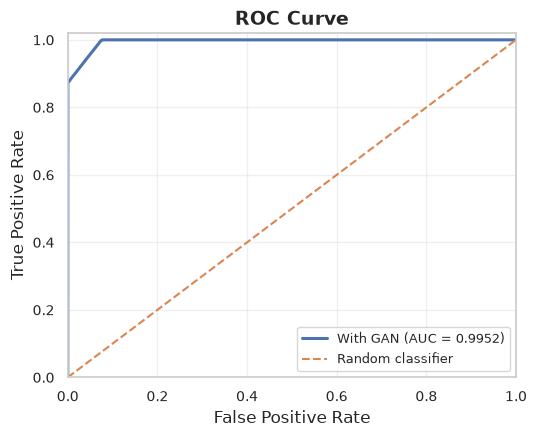


Saved -> /home/manasvi/sdn_notebook_final/artifacts/extended_results/figure3_roc_curve.png


In [42]:
# ---------------------------------------------------------------------------
# Figure 3 — ROC Curve
#
# Plots:
#   - Model ROC curve(s)
#   - AUC in legend
#   - Random-classifier diagonal
# ---------------------------------------------------------------------------

from sklearn.metrics import roc_curve, auc
import numpy as np
import os
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# 1. Check that classifiers are actually loaded
# ---------------------------------------------------------------------------

import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_PATHS = {
    
    "enas_with_gan": "artifacts/enas/best_model_gan.pt",
}


def load_classifier_for_experiment(exp_key):

    model_path = MODEL_PATHS[exp_key]

    print(f"Loading {exp_key} from:")
    print(model_path)

    ckpt = torch.load(
        model_path,
        map_location=DEVICE,
        weights_only=False
    )

    print(
        "Checkpoint keys:",
        list(ckpt.keys())
    )

    clf = ConfigurableMLP(
        ckpt["input_dim"],
        ckpt["architecture"]
    ).to(DEVICE)

    clf.load_state_dict(
        ckpt["state_dict"]
    )

    clf.eval()

    return clf


classifiers_for_plotting = {}



if "enas_with_gan" in results:
    classifiers_for_plotting[
        "enas_with_gan"
    ] = load_classifier_for_experiment(
        "enas_with_gan"
    )

print(
    "\nLoaded classifiers:",
    list(classifiers_for_plotting.keys())
)


# ---------------------------------------------------------------------------
# 2. Prepare labels
# ---------------------------------------------------------------------------

y_true = np.asarray(
    y_test_viz
).reshape(-1)

unique_classes = np.unique(
    y_true
)

if len(unique_classes) != 2:

    raise ValueError(
        "ROC curve requires a binary test set containing both classes.\n"
        f"Classes found: {unique_classes}"
    )


print(
    "Test samples:",
    len(y_true)
)

print(
    "Classes:",
    unique_classes
)


# ---------------------------------------------------------------------------
# 3. Create ROC figure
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5.5, 4.5)
)

model_curve_count = 0


# ---------------------------------------------------------------------------
# 4. Generate ROC curve for each loaded experiment
# ---------------------------------------------------------------------------

for exp_key, clf in classifiers_for_plotting.items():

    print(
        f"\nGenerating probabilities for: {exp_key}"
    )

    # --------------------------------------------------------
    # Get probability of ATTACK / positive class
    #
    # IMPORTANT:
    # predict_proba() should return a 1-D array containing
    # P(class = 1) for every test sample.
    # --------------------------------------------------------

    probs = predict_proba(
        clf,
        X_test_viz,
        device=DEVICE
    )

    probs = np.asarray(
        probs
    ).reshape(-1)


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if len(probs) != len(y_true):

        raise ValueError(
            f"Probability count mismatch for {exp_key}.\n"
            f"Labels      : {len(y_true)}\n"
            f"Probabilities: {len(probs)}"
        )


    if np.isnan(probs).any():

        raise ValueError(
            f"NaN probability values detected for {exp_key}."
        )


    print(
        "Probability range:",
        f"{probs.min():.6f}",
        "to",
        f"{probs.max():.6f}"
    )


    # --------------------------------------------------------
    # Calculate ROC
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_true,
        probs,
        pos_label=1
    )

    roc_auc_val = auc(
        fpr,
        tpr
    )


    # --------------------------------------------------------
    # Friendly experiment label
    # --------------------------------------------------------

   

    if exp_key == "enas_with_gan":

        exp_label = "With GAN"

    else:

        exp_label = exp_key


    # --------------------------------------------------------
    # Plot model ROC
    # --------------------------------------------------------

    ax.plot(
        fpr,
        tpr,
        linewidth=2.2,
        label=(
            f"{exp_label} "
            f"(AUC = {roc_auc_val:.4f})"
        )
    )

    model_curve_count += 1


    print(
        f"{exp_label} ROC-AUC: "
        f"{roc_auc_val:.6f}"
    )

    print(
        "ROC points:",
        len(fpr)
    )


# ---------------------------------------------------------------------------
# 5. Ensure at least one real ROC curve was plotted
# ---------------------------------------------------------------------------

if model_curve_count == 0:

    plt.close(fig)

    raise RuntimeError(
        "No model ROC curves were generated."
    )


# ---------------------------------------------------------------------------
# 6. Random classifier reference
# ---------------------------------------------------------------------------

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)


# ---------------------------------------------------------------------------
# 7. Formatting
# ---------------------------------------------------------------------------

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "ROC Curve",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    loc="lower right",
    fontsize=9
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()


# ---------------------------------------------------------------------------
# 8. Save
# ---------------------------------------------------------------------------

fig3_path = os.path.join(
    str(EXTENDED_RESULTS_DIR),
    "figure3_roc_curve.png"
)

plt.savefig(
    fig3_path,
    dpi=SAVE_DPI,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    f"\nSaved -> {fig3_path}"
)

Loading results from: artifacts/results/comparison_results.json

Available metric names:
['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'confusion_matrix', 'false_positive_rate', 'false_negative_rate', 'inference_latency_ms_per_flow']

ENAS With GAN Results
False Positive Rate: 0.077693 (7.77%)
False Negative Rate: 0.000007 (0.00%)


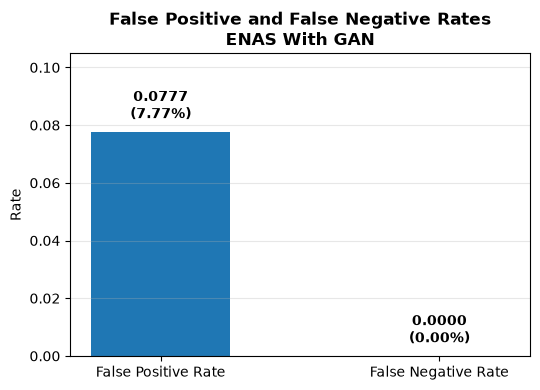


Saved -> artifacts/extended_results/figure4_gan_fpr_fnr.png


In [3]:
# ---------------------------------------------------------------------------
# Figure 4 — FPR and FNR for ENAS With GAN only
# ---------------------------------------------------------------------------

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Find comparison_results.json
# ------------------------------------------------------------

possible_paths = [
    Path("artifacts/results/comparison_results.json"),
    Path(
        "sdn_notebook_final/"
        "artifacts/results/"
        "comparison_results.json"
    )
]

comparison_results_path = None

for path in possible_paths:
    if path.exists():
        comparison_results_path = path
        break


if comparison_results_path is None:
    raise FileNotFoundError(
        "Could not find comparison_results.json"
    )


print(
    "Loading results from:",
    comparison_results_path
)


# ------------------------------------------------------------
# 2. Load results
# ------------------------------------------------------------

with open(
    comparison_results_path,
    "r",
    encoding="utf-8"
) as f:
    loaded_results = json.load(f)


# Handle either possible JSON structure
if "enas_with_gan" in loaded_results:

    results = loaded_results

elif (
    "experiments" in loaded_results
    and
    "enas_with_gan"
    in loaded_results["experiments"]
):

    results = loaded_results["experiments"]

else:

    raise KeyError(
        "'enas_with_gan' was not found.\n"
        f"Available keys: "
        f"{list(loaded_results.keys())}"
    )


# ------------------------------------------------------------
# 3. Get With-GAN test metrics
# ------------------------------------------------------------

gan_metrics = results[
    "enas_with_gan"
]["test_metrics"]


print(
    "\nAvailable metric names:"
)

print(
    list(gan_metrics.keys())
)


# ------------------------------------------------------------
# 4. Get FPR and FNR
# ------------------------------------------------------------

fpr_value = float(
    gan_metrics["false_positive_rate"]
)

fnr_value = float(
    gan_metrics["false_negative_rate"]
)


print("\nENAS With GAN Results")

print(
    f"False Positive Rate: "
    f"{fpr_value:.6f} "
    f"({fpr_value * 100:.2f}%)"
)

print(
    f"False Negative Rate: "
    f"{fnr_value:.6f} "
    f"({fnr_value * 100:.2f}%)"
)


# ------------------------------------------------------------
# 5. Create diagram
# ------------------------------------------------------------

names = [
    "False Positive Rate",
    "False Negative Rate"
]

values = [
    fpr_value,
    fnr_value
]


fig, ax = plt.subplots(
    figsize=(5.5, 4)
)

bars = ax.bar(
    names,
    values,
    width=0.5
)


# ------------------------------------------------------------
# 6. Add values above bars
# ------------------------------------------------------------

max_value = max(values)

label_offset = max(
    0.0005,
    max_value * 0.04
)


for bar, value in zip(
    bars,
    values
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + label_offset,

        f"{value:.4f}\n"
        f"({value * 100:.2f}%)",

        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

ax.set_ylabel(
    "Rate"
)

ax.set_title(
    "False Positive and False Negative Rates\n"
    "ENAS With GAN",
    fontsize=12,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)


# Make sure small FNR values remain visible
ax.set_ylim(
    0,
    max(
        0.01,
        max_value * 1.35
    )
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------

ARTIFACTS_DIR = (
    comparison_results_path
    .parent
    .parent
)

EXTENDED_RESULTS_DIR = (
    ARTIFACTS_DIR
    / "extended_results"
)

EXTENDED_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig4_path = (
    EXTENDED_RESULTS_DIR
    / "figure4_gan_fpr_fnr.png"
)

plt.savefig(
    fig4_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


print(
    f"\nSaved -> {fig4_path}"
)

In [24]:
# ---------------------------------------------------------------------------
# Figure 5 — Inference Latency Distribution
# ---------------------------------------------------------------------------

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

RANDOM_SEED = 42


@torch.no_grad()
def measure_latency_distribution(
    model,
    X,
    device=None,
    n_samples=2000,
    seed=RANDOM_SEED
):
    device = device or DEVICE

    model.eval()

    n_samples = min(
        n_samples,
        len(X)
    )

    rng = np.random.RandomState(seed)

    idx = rng.choice(
        len(X),
        size=n_samples,
        replace=False
    )

    X_t = torch.tensor(
        X[idx],
        dtype=torch.float32
    ).to(device)


    # Warm-up
    for i in range(
        min(10, n_samples)
    ):
        _ = model(
            X_t[i:i + 1]
        )

    if device.type == "cuda":
        torch.cuda.synchronize()


    latencies_ms = np.zeros(
        n_samples
    )


    for i in range(n_samples):

        t0 = time.perf_counter()

        _ = model(
            X_t[i:i + 1]
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        latencies_ms[i] = (
            time.perf_counter() - t0
        ) * 1000.0


    return latencies_ms


# ---------------------------------------------------------------------------
# Measure latency
# ---------------------------------------------------------------------------

print(
    "Available classifiers:",
    list(classifiers_for_plotting.keys())
)

if PRIMARY_EXPERIMENT_KEY in classifiers_for_plotting:

    primary_clf = classifiers_for_plotting[
        PRIMARY_EXPERIMENT_KEY
    ]

elif "No GAN" in classifiers_for_plotting:

    primary_clf = classifiers_for_plotting[
        "No GAN"
    ]

else:

    raise KeyError(
        "The No-GAN classifier has not been loaded.\n"
        f"Available keys: "
        f"{list(classifiers_for_plotting.keys())}"
    )

latency_samples = measure_latency_distribution(
    primary_clf,
    X_test_viz,
    device=DEVICE,
    n_samples=2000
)


# ---------------------------------------------------------------------------
# Summary statistics
# ---------------------------------------------------------------------------

mean_lat = latency_samples.mean()

median_lat = np.median(
    latency_samples
)

p95_lat = np.percentile(
    latency_samples,
    95
)

p99_lat = np.percentile(
    latency_samples,
    99
)


print(
    f"Inference latency "
    f"(ms/flow) over "
    f"{len(latency_samples)} samples "
    f"[{PRIMARY_EXPERIMENT_KEY}]:"
)

print(
    f"Mean   : {mean_lat:.4f} ms"
)

print(
    f"Median : {median_lat:.4f} ms"
)

print(
    f"P95    : {p95_lat:.4f} ms"
)

print(
    f"P99    : {p99_lat:.4f} ms"
)


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)


# Histogram
axes[0].hist(
    latency_samples,
    bins=40,
    edgecolor="black",
    alpha=0.85
)

axes[0].axvline(
    mean_lat,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_lat:.3f} ms"
)

axes[0].axvline(
    median_lat,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_lat:.3f} ms"
)

axes[0].axvline(
    p95_lat,
    linestyle=":",
    linewidth=2,
    label=f"P95 = {p95_lat:.3f} ms"
)

axes[0].axvline(
    p99_lat,
    linestyle=":",
    linewidth=2,
    label=f"P99 = {p99_lat:.3f} ms"
)

axes[0].set_xlabel(
    "Inference Latency per Flow (ms)"
)

axes[0].set_ylabel(
    "Frequency"
)

axes[0].set_title(
    "Latency Histogram",
    fontsize=12,
    fontweight="bold"
)

axes[0].legend(
    fontsize=8
)

axes[0].grid(
    alpha=0.3
)


# Boxplot
axes[1].boxplot(
    latency_samples,
    vert=True,
    showmeans=True
)

axes[1].set_ylabel(
    "Inference Latency per Flow (ms)"
)

axes[1].set_xticks([1])

axes[1].set_xticklabels(
    ["No GAN"]
)

axes[1].set_title(
    "Latency Boxplot",
    fontsize=12,
    fontweight="bold"
)

axes[1].grid(
    alpha=0.3
)


fig.suptitle(
    "Inference Latency Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()


# ---------------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------------

fig5_path = os.path.join(
    str(EXTENDED_RESULTS_DIR),
    "figure5_inference_latency_distribution.png"
)

plt.savefig(
    fig5_path,
    dpi=SAVE_DPI,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    f"Saved -> {fig5_path}"
)

Available classifiers: []


KeyError: 'The No-GAN classifier has not been loaded.\nAvailable keys: []'

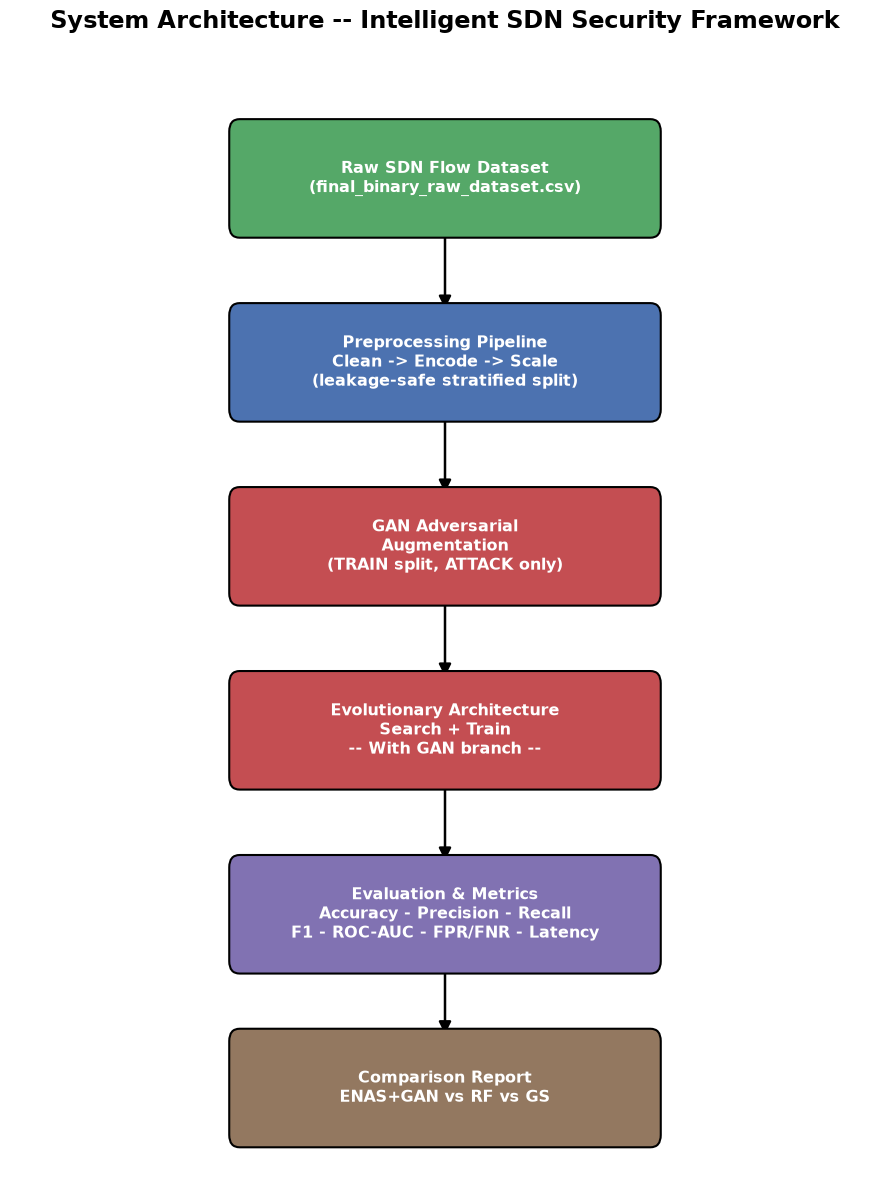

In [1]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt
import os

def draw_box(ax, center, text, width=4.8, height=1.0, facecolor="#4C72B0", fontsize=11.5, fontcolor="white"):
    x, y = center
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=1.5, edgecolor="black", facecolor=facecolor, zorder=2
    )
    ax.add_patch(box)
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=fontsize, color=fontcolor,
        fontweight="bold", zorder=3
    )

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color="black",
        zorder=1
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(9, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis("off")

positions = {
    "raw": (5, 9.8),
    "prep": (5, 8.0),
    "gan": (5, 6.2),
    "enas_gan": (5, 4.4),
    "eval": (5, 2.6),
    "compare": (5, 0.9),
}

draw_box(ax, positions["raw"],
         "Raw SDN Flow Dataset\n(final_binary_raw_dataset.csv)",
         facecolor="#55A868")

draw_box(ax, positions["prep"],
         "Preprocessing Pipeline\nClean -> Encode -> Scale\n(leakage-safe stratified split)",
         facecolor="#4C72B0")

draw_box(ax, positions["gan"],
         "GAN Adversarial\nAugmentation\n(TRAIN split, ATTACK only)",
         facecolor="#C44E52")

draw_box(ax, positions["enas_gan"],
         "Evolutionary Architecture\nSearch + Train\n-- With GAN branch --",
         facecolor="#C44E52")

draw_box(ax, positions["eval"],
         "Evaluation & Metrics\nAccuracy - Precision - Recall\nF1 - ROC-AUC - FPR/FNR - Latency",
         facecolor="#8172B2")

draw_box(ax, positions["compare"],
         "Comparison Report\nENAS+GAN vs RF vs GS",
         facecolor="#937860")

draw_arrow(ax, (5, 9.3), (5, 8.5))
draw_arrow(ax, (5, 7.5), (5, 6.7))
draw_arrow(ax, (5, 5.7), (5, 4.9))
draw_arrow(ax, (5, 3.9), (5, 3.1))
draw_arrow(ax, (5, 2.1), (5, 1.4))

ax.set_title("System Architecture -- Intelligent SDN Security Framework",
             fontsize=17, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

In [29]:
import torch

ckpt = torch.load(
    "artifacts/enas/best_model_no_gan.pt",
    map_location="cpu",
    weights_only=False
)

print("Checkpoint keys:")
print(ckpt.keys())

print("\nArchitecture:")
print(ckpt.get("architecture"))

print("\nInput dim:")
print(ckpt.get("input_dim"))

print("\nState dict keys:")
for key in ckpt["state_dict"].keys():
    print(key)

Checkpoint keys:
dict_keys(['state_dict', 'architecture', 'input_dim'])

Architecture:
{'n_layers': 4, 'activation': 'relu', 'dropout': 0.1, 'lr': 0.0001, 'batch_size': 256, 'units': [64, 64, 64, 64, 256]}

Input dim:
122

State dict keys:
net.0.weight
net.0.bias
net.1.weight
net.1.bias
net.1.running_mean
net.1.running_var
net.1.num_batches_tracked
net.4.weight
net.4.bias
net.5.weight
net.5.bias
net.5.running_mean
net.5.running_var
net.5.num_batches_tracked
net.8.weight
net.8.bias
net.9.weight
net.9.bias
net.9.running_mean
net.9.running_var
net.9.num_batches_tracked
net.12.weight
net.12.bias
net.13.weight
net.13.bias
net.13.running_mean
net.13.running_var
net.13.num_batches_tracked
net.16.weight
net.16.bias


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn

# ---------------------------------------------------------------------
# 1. Device (self-contained, doesn't rely on the Configuration cell)
# ---------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------
# 2. Model class (must match models/mlp.py exactly, since we're loading
#    weights trained with that architecture)
# ---------------------------------------------------------------------
ACTIVATIONS = {
    "relu": nn.ReLU,
    "leaky_relu": lambda: nn.LeakyReLU(0.01),
    "gelu": nn.GELU,
}

class ConfigurableMLP(nn.Module):
    def __init__(self, input_dim, arch):
        super().__init__()
        activation_cls = ACTIVATIONS[arch["activation"]]
        layers = []
        in_dim = input_dim
        for units in arch["units"][: arch["n_layers"]]:
            layers.append(nn.Linear(in_dim, units))
            layers.append(nn.BatchNorm1d(units))
            layers.append(activation_cls())
            if arch["dropout"] > 0:
                layers.append(nn.Dropout(arch["dropout"]))
            in_dim = units
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

@torch.no_grad()
def predict_proba(model, X, device=None, batch_size=2048):
    device = device or DEVICE
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    probs = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].to(device)
        logits = model(xb)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

# ---------------------------------------------------------------------
# 3. Paths (adjust PROJECT_ROOT if this notebook isn't in the folder
#    where 'artifacts/' was created)
# ---------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()
TEST_PATH = os.path.join(PROJECT_ROOT, "artifacts", "processed", "test.npz")
ENAS_DIR = os.path.join(PROJECT_ROOT, "artifacts", "enas")
model_paths = {
    "enas_no_gan": os.path.join(ENAS_DIR, "best_model_no_gan.pt"),
    "enas_with_gan": os.path.join(ENAS_DIR, "best_model_gan.pt"),
}

# ---------------------------------------------------------------------
# 4. The actual diagnostic
# ---------------------------------------------------------------------
test_data = np.load(TEST_PATH)
X_test_check, y_test_check = test_data["X"], test_data["y"]
print(f"Test set attack count: {(y_test_check == 1).sum()}")
print(f"Test set normal count: {(y_test_check == 0).sum()}")

for exp_key, model_path in model_paths.items():
    if not os.path.exists(model_path):
        print(f"{exp_key}: no saved checkpoint found at {model_path}, skipping.")
        continue

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    clf = ConfigurableMLP(ckpt["input_dim"], ckpt["architecture"]).to(DEVICE)
    clf.load_state_dict(ckpt["state_dict"])
    clf.eval()

    probs = predict_proba(clf, X_test_check, device=DEVICE)
    preds = (probs >= 0.5).astype(int)
    missed_attack_idx = np.where((y_test_check == 1) & (preds == 0))[0]
    print(f"{exp_key}: {len(missed_attack_idx)} missed attack(s), indices: {missed_attack_idx}")

Test set attack count: 150000
Test set normal count: 150000
enas_no_gan: 1 missed attack(s), indices: [244844]
enas_with_gan: 1 missed attack(s), indices: [244844]


---
# Part II — 3-Agent LFA Pipeline: Traffic Generation → Detection → Mitigation

The cells below **append** to the pipeline above without modifying any ENAS/GAN
training cells, `best_model_no_gan.pt`, `best_model_gan.pt`, or
`comparison_results.json`. They wire together three agents from the multi-agent
framework, all **fully offline / dataset-driven** (no Mininet/Ryu):

1. **Agent 1 — LFA Traffic Generation Agent**: the already-trained tabular GAN
   `Generator` reused frozen, with an epsilon-greedy **bandit controlling an
   adversarial evasion mode** (RL controls GAN mode; reward = attack objective −
   Detection Agent confidence).
2. **Agent 2 — Detection Agent**: the existing ENAS+GAN classifier, reused
   **frozen** (prefer `enas_with_gan`, trained to resist GAN-style synthetic
   attacks) — no retraining, no architecture change.
3. **Agent 3 — DQN Mitigation Agent**: a new DQN whose environment models
   **link congestion** (the LFA objective — many-flow crowding), trained offline.

**Train/val/test discipline:** synthetic LFA traffic is generated from / evaluated
against `val` (training episodes) and `test` (final evaluation) only, and is
**never** used to retrain the frozen ENAS+GAN classifier.

## Part II Configuration
New paths and hyperparameters (kept separate so no existing cell is modified).


In [ ]:
import os

# --------------------------------------------------------------------------
# New artifact directories / paths (existing files untouched)
# --------------------------------------------------------------------------
LFA_AGENT_DIR = os.path.join(ARTIFACTS_DIR, "lfa_agent")
DQN_MITIGATION_DIR = os.path.join(ARTIFACTS_DIR, "dqn_mitigation")
os.makedirs(LFA_AGENT_DIR, exist_ok=True)
os.makedirs(DQN_MITIGATION_DIR, exist_ok=True)

LFA_GENERATION_LOG_PATH = os.path.join(LFA_AGENT_DIR, "lfa_generation_log.json")
LFA_DETECTION_RESULTS_PATH = os.path.join(RESULTS_DIR, "lfa_detection_results.json")
FULL_LFA_PIPELINE_RESULTS_PATH = os.path.join(RESULTS_DIR, "full_lfa_pipeline_results.json")
DQN_MITIGATION_MODEL_PATH = os.path.join(DQN_MITIGATION_DIR, "mitigation_policy.pt")
DQN_TRAINING_HISTORY_PATH = os.path.join(RESULTS_DIR, "dqn_training_history.json")

# --------------------------------------------------------------------------
# Fixed action space — DO NOT reorder (assumed everywhere downstream)
#   0 = allow, 1 = monitor, 2 = rate_limit,
#   3 = install_blocking_rule (drop), 4 = reroute
# --------------------------------------------------------------------------
ACTION_ALLOW = 0
ACTION_MONITOR = 1
ACTION_RATE_LIMIT = 2
ACTION_BLOCK = 3          # install_blocking_rule (drop)
ACTION_REROUTE = 4
ACTION_NAMES = ["allow", "monitor", "rate_limit", "install_blocking_rule", "reroute"]
MITIGATION_ACTIONS = {ACTION_RATE_LIMIT, ACTION_BLOCK, ACTION_REROUTE}
N_ACTIONS = 5
MITIGATION_COST = {ACTION_RATE_LIMIT: 0.2, ACTION_BLOCK: 0.4, ACTION_REROUTE: 0.5}

# --------------------------------------------------------------------------
# Agent 1 — LFA generation / evasion bandit
# --------------------------------------------------------------------------
EVASION_STRENGTHS = [0.0, 0.25, 0.5, 0.75, 1.0]
LFA_BANDIT_ROUNDS = 60
LFA_BATCH_SIZE = 256
LFA_BANDIT_EPSILON = 0.2

# Episode mix ratio (normal / real-attack / synthetic-LFA)
MIX_NORMAL = 0.60
MIX_REAL_ATTACK = 0.20
MIX_SYNTH_LFA = 0.20

# --------------------------------------------------------------------------
# Agent 3 — DQN + LFA congestion dynamics
# --------------------------------------------------------------------------
DQN_WINDOW_SIZE = 256
DQN_N_EPISODES = 500
DQN_HIDDEN_DIMS = [128, 64]
DQN_GAMMA = 0.95
DQN_LR = 1e-3
DQN_BATCH_SIZE = 64
DQN_REPLAY_CAPACITY = 50_000
DQN_TARGET_UPDATE_FREQ = 500
DQN_EPS_START = 1.0
DQN_EPS_END = 0.05
DQN_EPS_DECAY_FRAC = 0.60
DQN_MIN_REPLAY = 1_000
DQN_GRAD_CLIP = 10.0

# LFA link-congestion model (many-flow crowding, NOT generic switch load)
CONGESTION_LFA_INCREMENT = 0.08    # per allowed malicious (LFA/attack) flow, clipped to 1.0
CONGESTION_MITIGATE_DECAY = 0.85   # when a malicious flow is mitigated
CONGESTION_NORMAL_DECAY = 0.98     # natural drain on a real NORMAL flow

log(f"Part II config ready. Artifacts -> {LFA_AGENT_DIR}, {DQN_MITIGATION_DIR}")
log(f"Action space: {list(enumerate(ACTION_NAMES))}")


In [ ]:
import json

import numpy as np
import torch

# --------------------------------------------------------------------------
# Reload preprocessed splits from disk so Part II is runnable independently.
# --------------------------------------------------------------------------
def _load_split(path):
    d = np.load(path)
    return d["X"].astype(np.float32), d["y"].astype(int)

val_X, val_y = _load_split(VAL_PATH)
test_X, test_y = _load_split(TEST_PATH)
FEATURE_DIM = val_X.shape[1]
STATE_DIM = FEATURE_DIM + 2   # pred_prob + features + congestion

with open(FEATURE_COLUMNS_PATH, "r") as f:
    FEATURE_NAMES = json.load(f)
FEATURE_INDEX = {name: i for i, name in enumerate(FEATURE_NAMES)}
log(f"Loaded splits -> val: {val_X.shape}, test: {test_X.shape}, features: {FEATURE_DIM}")


# ==========================================================================
# Agent 2 — Detection Agent (frozen, reuses the trained ENAS+GAN classifier)
# ==========================================================================
class DetectionAgent:
    """
    Frozen wrapper around the already-trained ConfigurableMLP classifier.
    eval() + sigmoid on the single logit, NO gradient updates — exactly matching
    how predict_proba is used elsewhere. `predict` accepts a single flow (1-D) or
    a batch (2-D) and returns (pred_prob, pred_label).
    """

    def __init__(self, model_path, device=None):
        self.device = device or DEVICE
        ckpt = torch.load(model_path, map_location=self.device, weights_only=False)
        self.input_dim = ckpt["input_dim"]
        self.architecture = ckpt["architecture"]
        self.model = ConfigurableMLP(self.input_dim, self.architecture).to(self.device)
        self.model.load_state_dict(ckpt["state_dict"])
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad_(False)
        self.model_path = model_path

    @torch.no_grad()
    def predict(self, x, batch_size=8192):
        arr = np.asarray(x, dtype=np.float32)
        single = arr.ndim == 1
        if single:
            arr = arr[None, :]
        probs = []
        for i in range(0, len(arr), batch_size):
            xb = torch.tensor(arr[i:i + batch_size], dtype=torch.float32, device=self.device)
            logits = self.model(xb)
            # robust to both squeeze / no-squeeze ConfigurableMLP variants
            probs.append(torch.sigmoid(logits).cpu().numpy().reshape(-1))
        probs = np.concatenate(probs)
        labels = (probs >= 0.5).astype(int)
        if single:
            return float(probs[0]), int(labels[0])
        return probs, labels


def _f1_of(path, X, y):
    from sklearn.metrics import f1_score
    _, labels = DetectionAgent(path).predict(X)
    return f1_score(y, labels, zero_division=0)


def select_detector_path():
    """
    Prefer enas_with_gan (it was specifically trained to be robust to GAN-style
    synthetic attacks, which is the realistic detector for the LFA-GAN scenario).
    Fall back to enas_no_gan if the GAN checkpoint is absent.
    """
    has_gan = os.path.exists(BEST_MODEL_GAN_PATH)
    has_no_gan = os.path.exists(BEST_MODEL_NO_GAN_PATH)
    if not (has_gan or has_no_gan):
        raise FileNotFoundError("No detector checkpoint found. Run the ENAS/GAN cells first.")

    if has_gan and has_no_gan:
        try:
            log(f"  detector test F1 -> gan={_f1_of(BEST_MODEL_GAN_PATH, test_X, test_y):.4f}, "
                f"no_gan={_f1_of(BEST_MODEL_NO_GAN_PATH, test_X, test_y):.4f}")
        except Exception as e:
            log(f"  (F1 comparison skipped: {e})")

    chosen = BEST_MODEL_GAN_PATH if has_gan else BEST_MODEL_NO_GAN_PATH
    why = "enas_with_gan (robust to synthetic attacks)" if has_gan else "enas_no_gan (only checkpoint)"
    log(f"Selected frozen Detection Agent: {why} -> {os.path.basename(chosen)}")
    return chosen


DETECTOR_PATH = select_detector_path()
detector = DetectionAgent(DETECTOR_PATH)
_p_check, _l_check = detector.predict(test_X[:4])
log(f"Detection Agent ready (sample pred_probs: {np.round(_p_check, 3)}).")


## 13. LFA Traffic Generation Agent

Agent 1 is a **generative model with RL-controlled adversarial mode** — it reuses
the tabular GAN `Generator` already trained on real ATTACK rows (`GAN_GENERATOR_PATH`),
**not** a from-scratch RL policy emitting raw packets.

- `LFAProfile` encodes what makes a flow *Link-Flooding-Attack-like* in this
  dataset's feature space, grounded in a **real sub-cluster of ATTACK rows** (not
  invented values): many low-and-slow flows converging on a shared bottleneck so
  no single flow looks like an obvious flood (high `pktps`/`bytps` relative to
  duration but not extreme single-flow volume; tight `pktAsm`/`bytAsm` and
  `duration` bands = coordinated crowding; concentrated toward the port/protocol
  bucket most correlated with the ATTACK class).
- `LFAGenerator` runs frozen-Generator noise through, then blends each sample
  toward the profile: `x_lfa = (1-e)·x_gan_raw + e·project_to_lfa_profile(x_gan_raw)`,
  keeping samples inside the learned manifold. The Generator is **never** unfrozen
  or fine-tuned here (a full LFA-specific conditional GAN is future work).
- `EvasionModeController` is an epsilon-greedy bandit over `evasion_strength` arms
  whose reward is `1 − DetectionAgent.mean_pred_prob` (high when the detector is
  *less* confident) — the adversarial reward from the framework.


In [ ]:
import numpy as np
import torch


# ==========================================================================
# LFAProfile — grounded in a REAL ATTACK sub-cluster of the val split
# ==========================================================================
def build_lfa_profile():
    """
    Compute target per-feature statistics from the sub-cluster of real ATTACK
    rows that best matches the LFA signature, so generation stays inside the
    actual data distribution rather than using hand-waved numbers.
    """
    Xa = val_X[val_y == 1]
    if len(Xa) == 0:
        raise ValueError("No ATTACK rows in val split to ground LFAProfile.")

    rate_feats = [f for f in ["pktps", "bytps"] if f in FEATURE_INDEX]
    asym_feats = [f for f in ["pktAsm", "bytAsm"] if f in FEATURE_INDEX]
    dur_feat = "duration" if "duration" in FEATURE_INDEX else None

    # LFA sub-cluster score: high rate (pktps+bytps) with SHORT/tight duration.
    # (LFA flows individually mimic legitimate traffic — high rate but coordinated
    #  and short — which is exactly what makes them evade naive flood detectors.)
    def zscore(col):
        return (col - col.mean()) / (col.std() + 1e-8)

    score = np.zeros(len(Xa))
    for f in rate_feats:
        score += zscore(Xa[:, FEATURE_INDEX[f]])
    if dur_feat:
        score -= zscore(Xa[:, FEATURE_INDEX[dur_feat]])   # prefer tighter/shorter duration

    k = max(50, int(0.30 * len(Xa)))          # top 30% as the LFA sub-cluster
    sub_idx = np.argsort(score)[-k:]
    Xsub = Xa[sub_idx]

    lfa_feats = list(rate_feats + asym_feats + ([dur_feat] if dur_feat else []))

    # Also concentrate toward the port-bucket / protocol feature most correlated
    # with the ATTACK class (log which one and why).
    cat_prefixes = ("l4Proto", "srcPort_bucket", "dstPort_bucket", "%dir",
                    "flowStat", "ethType", "vlanID")
    cat_like = [n for n in FEATURE_NAMES
                if n.startswith(cat_prefixes) or "_svc_" in n]
    y = val_y.astype(np.float32)
    best_cat, best_corr = None, 0.0
    for n in cat_like:
        col = val_X[:, FEATURE_INDEX[n]].astype(np.float32)
        if col.std() < 1e-8:
            continue
        c = np.corrcoef(col, y)[0, 1]
        if np.isfinite(c) and abs(c) > abs(best_corr):
            best_corr, best_cat = float(c), n
    if best_cat is not None and best_cat not in lfa_feats:
        lfa_feats.append(best_cat)

    target_mean = {n: float(Xsub[:, FEATURE_INDEX[n]].mean()) for n in lfa_feats}
    target_std = {n: float(Xsub[:, FEATURE_INDEX[n]].std()) for n in lfa_feats}

    log(f"LFAProfile grounded on {len(Xsub)} real-attack sub-cluster rows.")
    log(f"  projected LFA features : {lfa_feats}")
    log(f"  most ATTACK-correlated categorical/port feature: {best_cat} "
        f"(corr={best_corr:.3f}) — the LFA agent concentrates traffic here because "
        f"it is the strongest learned attack indicator in feature_columns.json.")

    return {
        "features": lfa_feats,
        "indices": [FEATURE_INDEX[n] for n in lfa_feats],
        "target_mean": target_mean,
        "target_std": target_std,
        "best_cat": best_cat,
        "best_corr": best_corr,
    }


LFA_PROFILE = build_lfa_profile()


# ==========================================================================
# LFAGenerator — frozen GAN Generator + profile projection
# ==========================================================================
def _from_unit_range(X_unit, X_min, X_max):
    """Invert the [-1, 1] rescaling used when the GAN was trained."""
    return ((X_unit + 1) / 2) * (X_max - X_min) + X_min


class LFAGenerator:
    def __init__(self, profile, gen_path=GAN_GENERATOR_PATH, device=None):
        self.device = device or DEVICE
        self.profile = profile

        if not os.path.exists(gen_path):
            # Fallback (keeps discipline): train a generator on VAL attack rows only.
            log(f"GAN generator not found at {gen_path}; training one on VAL attack rows...")
            train_gan_on_attack_samples(val_X, val_y, device=self.device)

        ckpt = torch.load(gen_path, map_location=self.device, weights_only=False)
        self.noise_dim = ckpt["noise_dim"]
        self.feature_dim = ckpt["feature_dim"]
        self.X_min = ckpt["X_min"]
        self.X_max = ckpt["X_max"]
        self.generator = Generator(self.noise_dim, self.feature_dim).to(self.device)
        self.generator.load_state_dict(ckpt["generator_state_dict"])
        self.generator.eval()
        for p in self.generator.parameters():     # frozen — compose only, never fine-tune
            p.requires_grad_(False)

        self.idx = np.array(profile["indices"], dtype=int)
        self.tmean = np.array([profile["target_mean"][n] for n in profile["features"]],
                              dtype=np.float32)

    def project_to_lfa_profile(self, X):
        """Shift ONLY the LFA-profile features toward their target mean (the
        'crowding' signature); all other features are left untouched so the
        vector stays on the Generator's learned manifold."""
        Xp = X.copy()
        for j, fi in enumerate(self.idx):
            Xp[:, fi] = self.tmean[j]
        return Xp

    @torch.no_grad()
    def generate_batch(self, batch_size, evasion_strength):
        z = torch.randn(batch_size, self.noise_dim, device=self.device)
        x_unit = self.generator(z).cpu().numpy()
        x_raw = _from_unit_range(x_unit, self.X_min, self.X_max).astype(np.float32)
        x_proj = self.project_to_lfa_profile(x_raw)
        e = float(evasion_strength)
        x_lfa = (1.0 - e) * x_raw + e * x_proj
        return x_lfa.astype(np.float32)


lfa_generator = LFAGenerator(LFA_PROFILE)
_demo = lfa_generator.generate_batch(8, 0.5)
log(f"LFAGenerator ready — sample batch shape {_demo.shape} (feature_dim={lfa_generator.feature_dim}).")


In [ ]:
import json

import numpy as np


# ==========================================================================
# EvasionModeController — epsilon-greedy bandit over evasion_strength arms
# ==========================================================================
class EvasionModeController:
    """
    RL-controlled adversarial mode (Section 2.4): each round it picks an
    evasion_strength arm, generates a batch, scores it with the frozen Detection
    Agent, and updates that arm's value estimate. Reward is high when the
    detector is LESS confident these are attacks:
        reward = 1 - detection_agent.predict(batch).mean_pred_prob
    """

    def __init__(self, arms=EVASION_STRENGTHS, epsilon=LFA_BANDIT_EPSILON, seed=RANDOM_SEED):
        self.arms = list(arms)
        self.values = np.zeros(len(self.arms))
        self.counts = np.zeros(len(self.arms))
        self.epsilon = epsilon
        self.rng = np.random.RandomState(seed)

    def select_arm(self):
        if self.rng.random() < self.epsilon:
            return self.rng.randint(len(self.arms))
        return int(np.argmax(self.values))

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

    def converged_strength(self):
        return self.arms[int(np.argmax(self.values))]


def run_evasion_bandit(generator, detector, rounds=LFA_BANDIT_ROUNDS,
                       batch_size=LFA_BATCH_SIZE):
    set_seed(RANDOM_SEED)
    ctrl = EvasionModeController()
    records = []

    for r in range(rounds):
        arm = ctrl.select_arm()
        e = ctrl.arms[arm]
        batch = generator.generate_batch(batch_size, e)
        probs, _ = detector.predict(batch)
        mean_p, std_p = float(probs.mean()), float(probs.std())
        reward = 1.0 - mean_p
        ctrl.update(arm, reward)

        records.append({
            "round": r + 1,
            "evasion_strength": e,
            "mean_pred_prob": mean_p,
            "std_pred_prob": std_p,
            "reward": reward,
            "arm_values": {str(a): float(v) for a, v in zip(ctrl.arms, ctrl.values)},
        })
        if (r + 1) % 10 == 0 or r == 0:
            log(f"  round {r + 1:3d} | e={e:.2f} | mean_pred_prob={mean_p:.3f} "
                f"| reward={reward:.3f}")

    with open(LFA_GENERATION_LOG_PATH, "w") as f:
        json.dump(records, f, indent=2)
    log(f"Saved LFA generation log -> {LFA_GENERATION_LOG_PATH}")

    conv = ctrl.converged_strength()
    log(f"Converged evasion_strength (argmax value estimate): {conv}")
    log(f"  per-arm value estimates: "
        f"{dict(zip(ctrl.arms, np.round(ctrl.values, 3)))}")
    return ctrl, records, conv


evasion_ctrl, lfa_gen_log, LFA_EVASION_STRENGTH = run_evasion_bandit(lfa_generator, detector)


## 14. Detection Agent: Evaluating LFA Traffic

Runs the **frozen** Detection Agent (Agent 2) against three populations for a
clean before/after picture: (a) real NORMAL, (b) real ATTACK, and (c) synthetic
LFA batches at each `evasion_strength` arm. For the real populations (ground
truth available) we report precision/recall/F1 on the combined real test set;
synthetic LFA batches are all-positive by construction, so only their detection
rate (mean predicted-attack label) is meaningful.


In [ ]:
import json

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


def _population_summary(name, X):
    probs, labels = detector.predict(X)
    return {
        "population": name,
        "n": int(len(X)),
        "mean_pred_prob": float(probs.mean()),
        "detection_rate@0.5": float(labels.mean()),
    }


# (a) real NORMAL, (b) real ATTACK — from the held-out test split
real_normal_X = test_X[test_y == 0]
real_attack_X = test_X[test_y == 1]

lfa_detection_results = {
    "detector": os.path.basename(DETECTOR_PATH),
    "real_normal": _population_summary("real_NORMAL", real_normal_X),
    "real_attack": _population_summary("real_ATTACK", real_attack_X),
    "synthetic_lfa_by_arm": {},
}

# precision/recall/F1 on the combined real test set (where ground truth exists)
_probs_all, _labels_all = detector.predict(test_X)
lfa_detection_results["real_combined"] = {
    "precision": float(precision_score(test_y, _labels_all, zero_division=0)),
    "recall": float(recall_score(test_y, _labels_all, zero_division=0)),
    "f1": float(f1_score(test_y, _labels_all, zero_division=0)),
}

# (c) synthetic LFA at each evasion arm (all-positive -> detection rate only)
for e in EVASION_STRENGTHS:
    batch = lfa_generator.generate_batch(LFA_BATCH_SIZE, e)
    summ = _population_summary(f"synthetic_LFA_e{e}", batch)
    summ["evasion_strength"] = e
    lfa_detection_results["synthetic_lfa_by_arm"][str(e)] = summ

with open(LFA_DETECTION_RESULTS_PATH, "w") as f:
    json.dump(lfa_detection_results, f, indent=2)
log(f"Saved LFA detection results -> {LFA_DETECTION_RESULTS_PATH}")

# --- readable table ---
rows = [
    {"population": "real_NORMAL",
     "mean_pred_prob": lfa_detection_results["real_normal"]["mean_pred_prob"],
     "detection_rate@0.5": lfa_detection_results["real_normal"]["detection_rate@0.5"]},
    {"population": "real_ATTACK",
     "mean_pred_prob": lfa_detection_results["real_attack"]["mean_pred_prob"],
     "detection_rate@0.5": lfa_detection_results["real_attack"]["detection_rate@0.5"]},
]
for e in EVASION_STRENGTHS:
    s = lfa_detection_results["synthetic_lfa_by_arm"][str(e)]
    rows.append({"population": f"synth_LFA (e={e})",
                 "mean_pred_prob": s["mean_pred_prob"],
                 "detection_rate@0.5": s["detection_rate@0.5"]})

detection_table = pd.DataFrame(rows)
rc = lfa_detection_results["real_combined"]
log(f"Real-test combined -> precision={rc['precision']:.3f}, "
    f"recall={rc['recall']:.3f}, F1={rc['f1']:.3f}")
print(detection_table.to_string(index=False))
detection_table


## 15. Simulated SDN Environment (LFA-centric)

A Gym-style **offline** environment whose episodes are explicitly LFA-centric:
each episode window is a shuffled mix of real NORMAL, real ATTACK, and Agent 1's
synthetic LFA flows (default 60/20/20, drawn from `val` for training and `test` +
fresh LFA for evaluation). The `congestion_signal` models **link congestion** (the
LFA objective — many-flow crowding): it rises by a larger step for each *allowed*
malicious flow (`+= 0.08`, clipped to 1.0) and decays when malicious flows are
mitigated (`× 0.85`) or on natural NORMAL drain (`× 0.98`).


In [ ]:
from collections import deque

import numpy as np


# ==========================================================================
# Shared congestion + reward helpers (used by env, full loop, and baseline)
# ==========================================================================
def apply_congestion_update(congestion, action, is_malicious):
    """
    LFA link-congestion dynamics. `is_malicious` == real ATTACK OR synthetic LFA.
    Allowed malicious flow -> +0.08 (crowding compounds, clipped to 1.0);
    mitigated malicious flow -> x0.85; any real NORMAL flow -> x0.98 (drain).
    """
    mitigated = action in MITIGATION_ACTIONS
    if is_malicious:
        if mitigated:
            congestion *= CONGESTION_MITIGATE_DECAY
        else:
            congestion = min(1.0, congestion + CONGESTION_LFA_INCREMENT)
    else:
        congestion *= CONGESTION_NORMAL_DECAY
    return congestion


def compute_mitigation_reward(action, true_label, is_synthetic_lfa=False, thrash=False):
    """Exact reward spec (auditable). malicious == (true ATTACK OR synthetic LFA)."""
    malicious = (true_label == 1) or is_synthetic_lfa
    mitigated = action in MITIGATION_ACTIONS

    base = 0.0
    if mitigated and malicious:
        base = 3.0 if action == ACTION_BLOCK else 2.0
    elif action == ACTION_ALLOW and not malicious:
        base = 1.0
    elif mitigated and not malicious:                    # collateral damage
        base = -2.0
        if action == ACTION_BLOCK:
            base += -1.0
    elif action == ACTION_ALLOW and malicious:           # attack/LFA let through
        base = -3.0
    elif action == ACTION_MONITOR:
        base = 0.1 if malicious else -0.1

    cost = MITIGATION_COST.get(action, 0.0)
    thrash_penalty = -0.5 if thrash else 0.0
    total = base - cost + thrash_penalty
    return total, {"base_reward": base, "cost_penalty": -cost, "thrash_penalty": thrash_penalty}


# ==========================================================================
# SDNMitigationEnv — mixed real + synthetic-LFA episodic environment
# ==========================================================================
class SDNMitigationEnv:
    def __init__(self, X, y, detector, lfa_generator, window_size=DQN_WINDOW_SIZE,
                 evasion_strength=None, mix=(MIX_NORMAL, MIX_REAL_ATTACK, MIX_SYNTH_LFA),
                 mode="train", seed=RANDOM_SEED):
        self.detector = detector
        self.lfa_generator = lfa_generator
        self.window_size = int(window_size)
        self.mode = mode
        self.mix = mix
        self.rng = np.random.RandomState(seed)
        self.evasion_strength = (evasion_strength if evasion_strength is not None
                                 else LFA_EVASION_STRENGTH)

        self.normal_X = np.asarray(X[y == 0], dtype=np.float32)
        self.attack_X = np.asarray(X[y == 1], dtype=np.float32)
        # frozen detector -> precompute real-pool pred_probs once
        self.normal_probs = self.detector.predict(self.normal_X)[0] if len(self.normal_X) else np.array([])
        self.attack_probs = self.detector.predict(self.attack_X)[0] if len(self.attack_X) else np.array([])

        self.feature_dim = X.shape[1]
        self.state_dim = self.feature_dim + 2
        self.n_actions = N_ACTIONS
        self._init_episode()

    def _init_episode(self):
        self.pos = 0
        self.congestion = 0.0
        self.recent_actions = deque(maxlen=3)
        self.consec_thrash = 0
        self.cong_sum = 0.0
        self.steps = 0
        self.n_mal = 0
        self.n_norm = 0
        self.false_mit = 0     # NORMAL mitigated
        self.missed = 0        # malicious NOT mitigated
        self.ep_feats = self.ep_probs = self.ep_labels = self.ep_synth = None

    def _sample(self, pool, probs, k):
        if len(pool) == 0 or k <= 0:
            return (np.empty((0, self.feature_dim), np.float32), np.empty((0,), np.float32))
        idx = self.rng.choice(len(pool), size=k, replace=len(pool) < k)
        return pool[idx], probs[idx]

    def reset(self):
        self._init_episode()
        w = self.window_size
        n_norm = int(self.mix[0] * w)
        n_att = int(self.mix[1] * w)
        n_lfa = w - n_norm - n_att

        norm_f, norm_p = self._sample(self.normal_X, self.normal_probs, n_norm)
        att_f, att_p = self._sample(self.attack_X, self.attack_probs, n_att)
        lfa_f = self.lfa_generator.generate_batch(n_lfa, self.evasion_strength)
        lfa_p = self.detector.predict(lfa_f)[0]

        feats = np.concatenate([norm_f, att_f, lfa_f], axis=0)
        probs = np.concatenate([norm_p, att_p, lfa_p])
        labels = np.concatenate([np.zeros(len(norm_f)), np.ones(len(att_f)),
                                 np.ones(len(lfa_f))]).astype(int)
        synth = np.concatenate([np.zeros(len(norm_f)), np.zeros(len(att_f)),
                                np.ones(len(lfa_f))]).astype(bool)

        order = self.rng.permutation(len(feats))
        self.ep_feats, self.ep_probs = feats[order], probs[order]
        self.ep_labels, self.ep_synth = labels[order], synth[order]
        return self._state(0)

    def _state(self, i):
        return np.concatenate(
            [[self.ep_probs[i]], self.ep_feats[i], [self.congestion]]
        ).astype(np.float32)

    def step(self, action):
        action = int(action)
        true_label = int(self.ep_labels[self.pos])
        is_syn = bool(self.ep_synth[self.pos])
        pred_prob = float(self.ep_probs[self.pos])
        malicious = (true_label == 1) or is_syn
        mitigated = action in MITIGATION_ACTIONS

        prev = self.congestion
        self.congestion = apply_congestion_update(self.congestion, action, malicious)
        decreased = self.congestion < prev - 1e-9
        if mitigated and not decreased:
            self.consec_thrash += 1
        else:
            self.consec_thrash = 0
        self.recent_actions.append(action)

        reward, breakdown = compute_mitigation_reward(
            action, true_label, is_syn, thrash=(self.consec_thrash >= 3)
        )

        self.steps += 1
        self.cong_sum += self.congestion
        if malicious:
            self.n_mal += 1
            if not mitigated:
                self.missed += 1
        else:
            self.n_norm += 1
            if mitigated:
                self.false_mit += 1

        self.pos += 1
        done = self.pos >= len(self.ep_labels)
        next_state = None if done else self._state(self.pos)

        info = {
            "true_label": true_label,
            "is_synthetic_lfa": is_syn,
            "pred_prob": pred_prob,
            "action": action,
            "congestion": self.congestion,
            "reward_breakdown": breakdown,
            "false_mitigation_count": self.false_mit,
            "missed_attack_count": self.missed,
        }
        return next_state, reward, done, info

    def episode_metrics(self, total_reward):
        return {
            "total_reward": float(total_reward),
            "mean_congestion": float(self.cong_sum / max(1, self.steps)),
            "false_mitigation_rate": float(self.false_mit / max(1, self.n_norm)),
            "missed_attack_rate": float(self.missed / max(1, self.n_mal)),
        }


_env = SDNMitigationEnv(val_X, val_y, detector, lfa_generator, mode="train")
_s = _env.reset()
log(f"SDNMitigationEnv OK — state_dim={_s.shape[0]}, window={len(_env.ep_labels)}, "
    f"evasion_strength={_env.evasion_strength}")


## 16. DQN Mitigation Agent

Agent 3: a Deep-Q-Network control policy (`QNetwork` `[128,64]`, `ReplayBuffer`,
`DQNAgent` with policy/target nets, epsilon-greedy, Huber TD loss, grad clipping).
Trained **offline on the `val` split + freshly generated LFA batches** — the frozen
ENAS+GAN classifier is never retrained.


In [ ]:
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn


class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dims=None):
        super().__init__()
        hidden_dims = hidden_dims or DQN_HIDDEN_DIMS
        layers = []
        in_dim = state_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, n_actions))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Fixed-capacity uniform replay. (Prioritized replay is a natural extension.)"""

    def __init__(self, capacity=DQN_REPLAY_CAPACITY):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.asarray(states, dtype=np.float32)
        actions = np.asarray(actions, dtype=np.int64)
        rewards = np.asarray(rewards, dtype=np.float32)
        dones = np.asarray(dones, dtype=np.float32)
        next_arr = np.zeros_like(states)
        for i, ns in enumerate(next_states):
            if ns is not None:
                next_arr[i] = ns
        return states, actions, rewards, next_arr, dones

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim, n_actions, device=None):
        self.device = device or DEVICE
        self.n_actions = n_actions
        self.gamma = DQN_GAMMA
        self.policy_net = QNetwork(state_dim, n_actions).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=DQN_LR)
        self.loss_fn = nn.SmoothL1Loss()   # Huber
        self.replay = ReplayBuffer(DQN_REPLAY_CAPACITY)
        self.learn_steps = 0

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.policy_net(s).argmax(dim=1).item())

    def train_step(self, batch_size):
        if len(self.replay) < max(batch_size, DQN_MIN_REPLAY):
            return None
        states, actions, rewards, next_states, dones = self.replay.sample(batch_size)
        states = torch.tensor(states, device=self.device)
        actions = torch.tensor(actions, device=self.device).unsqueeze(1)
        rewards = torch.tensor(rewards, device=self.device)
        next_states = torch.tensor(next_states, device=self.device)
        dones = torch.tensor(dones, device=self.device)

        q_values = self.policy_net(states).gather(1, actions).squeeze(1)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1)[0]
            td_target = rewards + self.gamma * next_q * (1.0 - dones)

        loss = self.loss_fn(q_values, td_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), DQN_GRAD_CLIP)
        self.optimizer.step()

        self.learn_steps += 1
        if self.learn_steps % DQN_TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
        return float(loss.item())


log("QNetwork / ReplayBuffer / DQNAgent defined.")


In [ ]:
import json
from collections import deque

import numpy as np
import torch


def train_dqn_mitigation(n_episodes=DQN_N_EPISODES, window_size=DQN_WINDOW_SIZE):
    set_seed(RANDOM_SEED)
    env = SDNMitigationEnv(val_X, val_y, detector, lfa_generator,
                           window_size=window_size, mode="train", seed=RANDOM_SEED)
    agent = DQNAgent(env.state_dim, env.n_actions)

    total_steps = n_episodes * window_size
    decay_steps = max(1, int(DQN_EPS_DECAY_FRAC * total_steps))
    gstep = 0
    history = []
    reward_window = deque(maxlen=20)
    sched_rng = np.random.RandomState(RANDOM_SEED)

    log(f"DQN offline training: {n_episodes} episodes x {window_size} flows "
        f"= {total_steps} steps.")

    for ep in range(n_episodes):
        # Evasion-strength schedule: mostly the converged (strongest) strength for
        # realism, occasionally a random arm so the policy stays robust to weaker /
        # other evasion levels rather than overfitting to a single adversary mode.
        if sched_rng.random() < 0.7:
            env.evasion_strength = LFA_EVASION_STRENGTH
        else:
            env.evasion_strength = float(sched_rng.choice(EVASION_STRENGTHS))

        state = env.reset()
        done = False
        ep_reward = 0.0
        losses = []
        epsilon = DQN_EPS_START

        while not done:
            frac = min(1.0, gstep / decay_steps)
            epsilon = DQN_EPS_START + frac * (DQN_EPS_END - DQN_EPS_START)
            action = agent.select_action(state, epsilon)
            next_state, reward, done, info = env.step(action)
            agent.replay.push(state, action, reward, next_state, float(done))
            loss = agent.train_step(DQN_BATCH_SIZE)
            if loss is not None:
                losses.append(loss)
            state = next_state if not done else state
            ep_reward += reward
            gstep += 1

        m = env.episode_metrics(ep_reward)
        reward_window.append(ep_reward)
        m.update({
            "episode": ep + 1,
            "epsilon": float(epsilon),
            "evasion_strength": float(env.evasion_strength),
            "moving_avg_reward_20": float(np.mean(reward_window)),
            "mean_loss": float(np.mean(losses)) if losses else None,
        })
        history.append(m)

        if (ep + 1) % 25 == 0 or ep == 0 or ep == n_episodes - 1:
            log(f"  ep {ep + 1:4d}/{n_episodes} | R={ep_reward:8.2f} "
                f"| avg20={m['moving_avg_reward_20']:8.2f} | eps={epsilon:.3f} "
                f"| cong={m['mean_congestion']:.3f} | false_mit={m['false_mitigation_rate']:.3f} "
                f"| missed={m['missed_attack_rate']:.3f}")

    torch.save({
        "state_dict": agent.policy_net.state_dict(),
        "state_dim": env.state_dim,
        "n_actions": env.n_actions,
        "hidden_dims": DQN_HIDDEN_DIMS,
        "action_names": ACTION_NAMES,
        "detector_path": DETECTOR_PATH,
        "converged_evasion_strength": LFA_EVASION_STRENGTH,
    }, DQN_MITIGATION_MODEL_PATH)
    log(f"Saved DQN mitigation policy -> {DQN_MITIGATION_MODEL_PATH}")

    with open(DQN_TRAINING_HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)
    log(f"Saved DQN training history -> {DQN_TRAINING_HISTORY_PATH}")

    last = history[-min(20, len(history)):]
    log("\n===== DQN TRAINING SUMMARY (last 20 episodes) =====")
    log(f"  mean reward           : {np.mean([h['total_reward'] for h in last]):.3f}")
    log(f"  false-mitigation rate : {np.mean([h['false_mitigation_rate'] for h in last]):.4f}")
    log(f"  missed-attack rate    : {np.mean([h['missed_attack_rate'] for h in last]):.4f}")
    log(f"  mean congestion       : {np.mean([h['mean_congestion'] for h in last]):.4f}")
    return agent, history


dqn_agent, dqn_history = train_dqn_mitigation()


## 17. Full Multi-Agent Loop: Generate → Detect → Mitigate

Closes the loop end-to-end on the **held-out test set + fresh LFA batches** (test
only — no val leakage). Agent 1 generates LFA flows at its converged
`evasion_strength`; a `DefenderPipeline` (frozen Detection Agent + trained DQN
policy, argmax / no exploration) runs each flow — interleaved with real test flows
at the mix ratio — through detection then mitigation; the environment's
`congestion_signal` is updated and fed back as the next step's state.

The identical stream is also run through a **static-threshold baseline**
(`drop if pred_prob > 0.5 else allow`) so Section 18 can compare congestion
recovery (the metric that matters for LFA).


In [ ]:
import json

import numpy as np
import torch


# ==========================================================================
# DefenderPipeline — frozen Detection Agent + trained DQN policy (argmax)
# ==========================================================================
class DefenderPipeline:
    def __init__(self, detector, policy_path=DQN_MITIGATION_MODEL_PATH, device=None):
        self.device = device or DEVICE
        self.detector = detector
        ckpt = torch.load(policy_path, map_location=self.device, weights_only=False)
        self.mitigator = QNetwork(ckpt["state_dim"], ckpt["n_actions"],
                                  ckpt.get("hidden_dims")).to(self.device)
        self.mitigator.load_state_dict(ckpt["state_dict"])
        self.mitigator.eval()

    @torch.no_grad()
    def act(self, pred_prob, flow_x, congestion):
        state = np.concatenate([[pred_prob], np.asarray(flow_x, np.float32), [congestion]]).astype(np.float32)
        s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        return int(self.mitigator(s).argmax(dim=1).item())


# ==========================================================================
# Shared evaluation stream: full test set + fresh LFA at the mix ratio
# ==========================================================================
def build_eval_stream(seed=RANDOM_SEED):
    rng = np.random.RandomState(seed)
    n_real = len(test_X)
    # synthetic LFA make up MIX_SYNTH_LFA of the total; real test keeps its split
    n_lfa = int(round(MIX_SYNTH_LFA / (MIX_NORMAL + MIX_REAL_ATTACK) * n_real))
    lfa = lfa_generator.generate_batch(n_lfa, LFA_EVASION_STRENGTH)

    feats = np.concatenate([test_X, lfa], axis=0).astype(np.float32)
    labels = np.concatenate([test_y, np.ones(n_lfa)]).astype(int)
    synth = np.concatenate([np.zeros(n_real), np.ones(n_lfa)]).astype(bool)

    order = rng.permutation(len(feats))
    feats, labels, synth = feats[order], labels[order], synth[order]
    probs, _ = detector.predict(feats)      # frozen detector, precomputed once
    return feats, labels, synth, probs


def _subpop(true_label, is_syn):
    if is_syn:
        return "synthetic_LFA"
    return "real_ATTACK" if true_label == 1 else "real_NORMAL"


def run_policy(feats, labels, synth, probs, pipeline=None, policy="dqn"):
    congestion = 0.0
    consec = 0
    trajectory = []
    action_counts = {s: np.zeros(N_ACTIONS) for s in ["real_NORMAL", "real_ATTACK", "synthetic_LFA"]}
    false_mit = missed = 0
    n_norm = n_mal = 0
    total_reward = total_cost = 0.0
    lfa_total = lfa_detected = lfa_mitigated = 0

    for i in range(len(feats)):
        p = float(probs[i]); tl = int(labels[i]); syn = bool(synth[i])
        malicious = (tl == 1) or syn

        if policy == "static":
            action = ACTION_BLOCK if p > 0.5 else ACTION_ALLOW
        else:
            action = pipeline.act(p, feats[i], congestion)

        mitigated = action in MITIGATION_ACTIONS
        action_counts[_subpop(tl, syn)][action] += 1

        if syn:
            lfa_total += 1
            if p > 0.5:
                lfa_detected += 1       # detection by the classifier (before mitigation)
            if mitigated:
                lfa_mitigated += 1      # actually acted on by the mitigation agent

        prev = congestion
        congestion = apply_congestion_update(congestion, action, malicious)
        decreased = congestion < prev - 1e-9
        consec = consec + 1 if (mitigated and not decreased) else 0
        reward, bd = compute_mitigation_reward(action, tl, syn, thrash=(consec >= 3))
        total_reward += reward
        total_cost += -bd["cost_penalty"]

        if malicious:
            n_mal += 1
            if not mitigated:
                missed += 1
        else:
            n_norm += 1
            if mitigated:
                false_mit += 1
        trajectory.append(congestion)

    n = len(feats)
    dist = {sub: {ACTION_NAMES[a]: float(action_counts[sub][a] / max(1, action_counts[sub].sum()))
                  for a in range(N_ACTIONS)}
            for sub in action_counts}
    return {
        "policy": policy,
        "n_flows": int(n),
        "lfa_detection_rate_before": float(lfa_detected / max(1, lfa_total)),
        "lfa_mitigation_rate_after": float(lfa_mitigated / max(1, lfa_total)),
        "missed_attack_rate": float(missed / max(1, n_mal)),
        "false_mitigation_rate": float(false_mit / max(1, n_norm)),
        "mean_reward_per_flow": float(total_reward / max(1, n)),
        "mean_cost_per_flow": float(total_cost / max(1, n)),
        "final_congestion": float(trajectory[-1] if trajectory else 0.0),
        "mean_congestion": float(np.mean(trajectory) if trajectory else 0.0),
        "action_distribution_by_subpop": dist,
        "congestion_trajectory": [float(c) for c in trajectory],
    }


def steps_to_recover(policy, pipeline=None, start_congestion=1.0,
                     threshold=0.2, max_steps=300, seed=RANDOM_SEED):
    """
    MTTM stand-in: start at high link congestion, feed a stream of malicious LFA
    flows, and count steps until congestion falls below `threshold`. Under a
    static detector-threshold policy, LFA flows that evade detection (prob <= 0.5)
    are ALLOWED and congestion never drains — exactly the LFA failure mode.
    """
    rng = np.random.RandomState(seed)
    lfa = lfa_generator.generate_batch(max_steps, LFA_EVASION_STRENGTH)
    probs, _ = detector.predict(lfa)
    congestion = start_congestion
    for t in range(max_steps):
        p = float(probs[t])
        if policy == "static":
            action = ACTION_BLOCK if p > 0.5 else ACTION_ALLOW
        else:
            action = pipeline.act(p, lfa[t], congestion)
        congestion = apply_congestion_update(congestion, action, is_malicious=True)
        if congestion < threshold:
            return t + 1
    return max_steps


# ---------------------------------------------------------------------------
# Run the full loop (DQN) and the static baseline over the SAME stream
# ---------------------------------------------------------------------------
set_seed(RANDOM_SEED)
defender_pipeline = DefenderPipeline(detector)
stream_feats, stream_labels, stream_synth, stream_probs = build_eval_stream()

dqn_run = run_policy(stream_feats, stream_labels, stream_synth, stream_probs,
                     pipeline=defender_pipeline, policy="dqn")
static_run = run_policy(stream_feats, stream_labels, stream_synth, stream_probs,
                        policy="static")

dqn_run["steps_to_congestion_below_0.2"] = steps_to_recover("dqn", pipeline=defender_pipeline)
static_run["steps_to_congestion_below_0.2"] = steps_to_recover("static")

full_results = {
    "detector": os.path.basename(DETECTOR_PATH),
    "converged_evasion_strength": LFA_EVASION_STRENGTH,
    "mix_ratio": {"normal": MIX_NORMAL, "real_attack": MIX_REAL_ATTACK, "synthetic_lfa": MIX_SYNTH_LFA},
    "dqn_mitigation": dqn_run,
    "static_baseline": static_run,
}
with open(FULL_LFA_PIPELINE_RESULTS_PATH, "w") as f:
    json.dump(full_results, f, indent=2)
log(f"Saved full LFA pipeline results -> {FULL_LFA_PIPELINE_RESULTS_PATH}")

log("\n===== FULL MULTI-AGENT LOOP (TEST + fresh LFA) =====")
for name, run in [("DQN Mitigation Agent", dqn_run), ("Static threshold", static_run)]:
    log(f"[{name}]")
    log(f"  LFA detection rate (before mitigation): {run['lfa_detection_rate_before']:.4f}")
    log(f"  LFA mitigation rate (after)           : {run['lfa_mitigation_rate_after']:.4f}")
    log(f"  missed-attack rate                    : {run['missed_attack_rate']:.4f}")
    log(f"  false-mitigation rate                 : {run['false_mitigation_rate']:.4f}")
    log(f"  mean reward / flow                    : {run['mean_reward_per_flow']:.4f}")
    log(f"  steps to congestion < 0.2             : {run['steps_to_congestion_below_0.2']}")
log("\nDQN action distribution on synthetic-LFA sub-population:")
for name, frac in dqn_run["action_distribution_by_subpop"]["synthetic_LFA"].items():
    log(f"  {name:22s}: {frac*100:5.2f}%")


## 18. Evaluation: LFA Generation, Detection, and Mitigation

Five views: (1) the evasion bandit's per-arm value estimates over rounds,
(2) detector mean `pred_prob` on synthetic-LFA vs real-ATTACK vs real-NORMAL,
(3) DQN training curves, (4) congestion recovery under DQN vs. the static
baseline, and (5) a markdown summary table. Reuses `SAVE_DPI` /
`EXTENDED_RESULTS_DIR` from the earlier plotting cells (with safe fallbacks).


In [ ]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt

# Fallbacks if the earlier plotting cells weren't run this session.
if "EXTENDED_RESULTS_DIR" not in globals():
    from pathlib import Path
    EXTENDED_RESULTS_DIR = Path(ARTIFACTS_DIR) / "extended_results"
    EXTENDED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
if "SAVE_DPI" not in globals():
    SAVE_DPI = 150


# --------------------------------------------------------------------------
# (1) Evasion bandit per-arm value estimates over rounds
# --------------------------------------------------------------------------
with open(LFA_GENERATION_LOG_PATH) as f:
    gen_log = json.load(f)

rounds = [r["round"] for r in gen_log]
arm_series = {str(a): [r["arm_values"][str(a)] for r in gen_log] for a in EVASION_STRENGTHS}

fig, ax = plt.subplots(figsize=(8, 4.5))
for a in EVASION_STRENGTHS:
    ax.plot(rounds, arm_series[str(a)], linewidth=1.8, label=f"e={a}")
ax.set_xlabel("Bandit round")
ax.set_ylabel("Arm value estimate  (1 − detector confidence)")
ax.set_title("LFA Evasion Controller — Per-Arm Value Estimates", fontweight="bold")
ax.legend(title="evasion_strength", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig8 = os.path.join(str(EXTENDED_RESULTS_DIR), "figure8_evasion_arm_values.png")
plt.savefig(fig8, dpi=SAVE_DPI, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved -> {fig8}  (converged evasion_strength = {LFA_EVASION_STRENGTH})")


# --------------------------------------------------------------------------
# (2) Detector mean pred_prob: synthetic-LFA vs real-ATTACK vs real-NORMAL
# --------------------------------------------------------------------------
with open(LFA_DETECTION_RESULTS_PATH) as f:
    det_res = json.load(f)

conv_key = str(LFA_EVASION_STRENGTH)
pops = ["real_NORMAL", "real_ATTACK", f"synthetic_LFA\n(e={LFA_EVASION_STRENGTH})"]
vals = [
    det_res["real_normal"]["mean_pred_prob"],
    det_res["real_attack"]["mean_pred_prob"],
    det_res["synthetic_lfa_by_arm"][conv_key]["mean_pred_prob"],
]
colors = ["#55A868", "#4C72B0", "#C44E52"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(pops, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
            ha="center", va="bottom", fontweight="bold")
ax.axhline(0.5, linestyle="--", color="black", linewidth=1, label="decision threshold")
ax.set_ylabel("Mean detector pred_prob")
ax.set_ylim(0, 1.05)
ax.set_title("Detection Agent Confidence by Population", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig9 = os.path.join(str(EXTENDED_RESULTS_DIR), "figure9_detector_confidence_by_population.png")
plt.savefig(fig9, dpi=SAVE_DPI, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved -> {fig9}")


In [ ]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
    _HAS_IPY = True
except Exception:
    _HAS_IPY = False


# --------------------------------------------------------------------------
# (3) DQN training curves
# --------------------------------------------------------------------------
with open(DQN_TRAINING_HISTORY_PATH) as f:
    hist = json.load(f)

eps = [h["episode"] for h in hist]
mov = np.array([h["moving_avg_reward_20"] for h in hist])
rew = np.array([h["total_reward"] for h in hist])
fmr = np.array([h["false_mitigation_rate"] for h in hist])
mar = np.array([h["missed_attack_rate"] for h in hist])
cong = np.array([h["mean_congestion"] for h in hist])

fig, axes = plt.subplots(3, 1, figsize=(9, 11))
axes[0].plot(eps, rew, alpha=0.35, label="Episode reward")
axes[0].plot(eps, mov, linewidth=2.2, label="20-episode moving avg")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Total reward")
axes[0].set_title("DQN Mitigation — Episode Reward", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9); axes[0].grid(alpha=0.3)

axb = axes[1]; axb2 = axb.twinx()
l1, = axb.plot(eps, fmr, color="#C44E52", linewidth=1.8, label="False-mitigation rate")
l2, = axb2.plot(eps, mar, color="#4C72B0", linewidth=1.8, label="Missed-attack rate")
axb.set_xlabel("Episode"); axb.set_ylabel("False-mitigation rate", color="#C44E52")
axb2.set_ylabel("Missed-attack rate", color="#4C72B0")
axb.tick_params(axis="y", labelcolor="#C44E52"); axb2.tick_params(axis="y", labelcolor="#4C72B0")
axb.set_title("DQN Mitigation — Error Rates over Training", fontweight="bold")
axb.legend(handles=[l1, l2], loc="upper right", fontsize=9); axb.grid(alpha=0.3)

axes[2].plot(eps, cong, color="#55A868", linewidth=1.8)
axes[2].set_xlabel("Episode"); axes[2].set_ylabel("Mean congestion")
axes[2].set_title("DQN Mitigation — Mean Link Congestion per Episode", fontweight="bold")
axes[2].grid(alpha=0.3)

plt.tight_layout()
fig10 = os.path.join(str(EXTENDED_RESULTS_DIR), "figure10_dqn_training_curves.png")
plt.savefig(fig10, dpi=SAVE_DPI, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved -> {fig10}")


# --------------------------------------------------------------------------
# (4) Congestion trajectory: DQN vs static baseline (same LFA stream)
# --------------------------------------------------------------------------
with open(FULL_LFA_PIPELINE_RESULTS_PATH) as f:
    full = json.load(f)

dqn_traj = np.array(full["dqn_mitigation"]["congestion_trajectory"])
stat_traj = np.array(full["static_baseline"]["congestion_trajectory"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(stat_traj, color="#937860", linewidth=1.4, alpha=0.9, label="Static threshold")
ax.plot(dqn_traj, color="#C44E52", linewidth=1.4, alpha=0.9, label="DQN Mitigation Agent")
ax.set_xlabel("Flow step (test + fresh LFA)")
ax.set_ylabel("Link congestion signal")
ax.set_title("Link Congestion over Full-Loop Evaluation — DQN vs. Static Baseline",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig11 = os.path.join(str(EXTENDED_RESULTS_DIR), "figure11_congestion_dqn_vs_static.png")
plt.savefig(fig11, dpi=SAVE_DPI, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved -> {fig11}")


# --------------------------------------------------------------------------
# (5) Markdown summary table
# --------------------------------------------------------------------------
def _row(name, run):
    return {
        "Policy": name,
        "LFA detection rate": run["lfa_mitigation_rate_after"],
        "Missed-attack rate": run["missed_attack_rate"],
        "False-mitigation rate": run["false_mitigation_rate"],
        "Steps to congestion < 0.2": run["steps_to_congestion_below_0.2"],
    }

summary_rows = [
    _row("Static threshold", full["static_baseline"]),
    _row("DQN Mitigation Agent", full["dqn_mitigation"]),
]
summary_df = pd.DataFrame(summary_rows).set_index("Policy")

summary_csv = os.path.join(RESULTS_DIR, "lfa_mitigation_comparison_table.csv")
summary_df.to_csv(summary_csv)
print(f"Saved -> {summary_csv}")

md = ["| Policy | LFA detection rate | Missed-attack rate | False-mitigation rate | Steps to congestion < 0.2 |",
      "|---|---|---|---|---|"]
for r in summary_rows:
    md.append(f"| {r['Policy']} | {r['LFA detection rate']:.4f} | {r['Missed-attack rate']:.4f} | "
              f"{r['False-mitigation rate']:.4f} | {int(r['Steps to congestion < 0.2'])} |")
md_table = "\n".join(md)

if _HAS_IPY:
    display(Markdown("### LFA Mitigation: Static Baseline vs. DQN (TEST + fresh LFA)\n\n" + md_table))
else:
    print("\nLFA Mitigation: Static Baseline vs. DQN (TEST + fresh LFA)\n")
    print(md_table)

summary_df
